<a href="https://colab.research.google.com/github/ParkHangah/AIFFEL_quest_eng/blob/master/Main_Quest/Quest01/Aiffel_MainQuest_01_Kaggle_spaceship_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Space Titanic**

## 퀘스트 내용
* 2912년 성간 여객선 타이타닉호가 항해 중 시공간 이상현상과 충돌하여 승객 절반이 다른 차원으로 이동했다.
* 복구된 2/3 약 8700명의 승객 데이터를 이용하여 미복구된 1/3 약 4300명의 차원 이동여부를 예측하라


### 제공 데이터
#### train.csv
전체 승객의 약 3분의 2(약 8700명)에 대한 개인 기록으로, 학습 데이터로 사용될 예정
* PassengerId- 각 승객에게는 고유 ID가 부여됩니다. 각 ID는 <그룹 번호> 형식으로 되어 있으며, < gggg_pp그룹 번호 gggg>는 승객이 속한 그룹을 나타내고 < pp그룹 내 번호>는 그룹 내 승객의 순번입니다. 그룹 구성원은 대개 가족이지만 항상 그런 것은 아닙니다.
* HomePlanet- 승객이 출발한 행성, 일반적으로는 영구 거주지 행성.
* CryoSleep- 승객이 항해 기간 동안 동면 상태에 들어가는 것을 선택했는지 여부를 나타냅니다. 동면 상태에 들어간 승객은 객실에 격리됩니다.
* Cabin- 승객이 투숙하는 객실 번호입니다. 형식은 이며 deck/num/side, 는 side좌현 P( Port) 또는 S우현 (Starboard)을 나타냅니다 .
* Destination- 승객이 하선할 행성.
* Age- 승객의 나이.
* VIP- 승객이 항해 중 특별 VIP 서비스를 유료로 이용했는지 여부.
* RoomService- 승객이 타이타닉FoodCourt 호의 다양한 고급 편의시설 ShoppingMall각각 에서 지불한 금액 Spa.VRDeck
* Name- 승객의 이름(성 및 이름).
* Transported- 승객이 다른 차원으로 이동했는지 여부. 이것이 바로 예측하려는 목표, 즉 핵심 변수입니다.
#### test.csv
나머지 3분의 1(약 4300명) 승객의 개인 기록이 포함된 테스트 데이터.
#### sample_submission.csv
제출 파일 형식.
* PassengerId- 테스트 세트에 포함된 각 승객의 ID입니다.
* Transported- 목표. 각 승객에 대해 또는 를 예측 True합니다 False.

## 1. 데이터 연결

In [110]:
# 드라이브 마운트
from google.colab import drive
from IPython.display import clear_output
import ipywidgets as widgets
import os

def inf(msg, style, wdth): inf = widgets.Button(description=msg, disabled=True, button_style=style, layout=widgets.Layout(min_width=wdth));display(inf)

print("[0;33mConnecting...")
drive.mount('/content/gdrive')

mainpth="MyDrive"

clear_output()
inf('\u2714 Done','success', '50px')

Button(button_style='success', description='✔ Done', disabled=True, layout=Layout(min_width='50px'), style=But…

In [2]:
# # 필요한 라이브러리 및 모듈 임포트 - 캉골에서 제공하는 스타터 노트
# import tensorflow_decision_forests as tfdf
# import pandas as pdimport xgboost as xgb

**YDF (Yggdrasil Decision Forests)**는 tensorflow_decision_forests(TF-DF)의 후속 라이브러리로, 더 빠르고 간결한 코드를 지원한다고 한다.

In [3]:
# 필요한 라이브러리 및 모듈 임포트
# 데이터 분석 및 전처리
import ydf
import numpy as np
import pandas as pd
import xgboost as xgb # 데이터 정형
import missingno as msno # 결측치 시각화
# 데이터 분할 및 평가 도구
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import lightgbm as lgb
# 데이터 시각화
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 데이터 불러오기 및 데이터 확인
train = pd.read_csv('/content/gdrive/MyDrive/#Study/Aiffel/Work/Kaggle/spaceship_titanic/train.csv')
test = pd.read_csv('/content/gdrive/MyDrive/#Study/Aiffel/Work/Kaggle/spaceship_titanic/test.csv')

In [5]:
print(f'train data dim : {train.shape}')
train.head()

train data dim : (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [6]:
print(f'test data dim : {test.shape}')
test.head()

test data dim : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


## 2. 데이터 전처리 (1) 데이터 확인하기

### 2-1. train 데이터와 test 데이터 합치기 (why? 데이터 전처리를 한번에 하기 위해)

In [7]:
# 트레인 데이터에서 결과값 분리하기
y = train['Transported']
del train['Transported']

print(train.columns)
print(y)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name'],
      dtype='object')
0       False
1        True
2       False
3       False
4        True
        ...  
8688    False
8689    False
8690     True
8691    False
8692     True
Name: Transported, Length: 8693, dtype: bool


In [8]:
# train 데이터와 test 데이터 합치기 (why? 데이터 전처리를 한번에 하기 위해)
train_len = len(train)
data = pd.concat([train, test], axis=0, ignore_index=True)
print(train_len, data.shape)

8693 (12970, 13)


In [9]:
data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines


### 2-3. 데이터 형태와 결측치 확인

In [63]:
# 각필드의 데이터 타입 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    12970 non-null  object 
 1   HomePlanet     12682 non-null  object 
 2   CryoSleep      12660 non-null  object 
 3   Cabin          12671 non-null  object 
 4   Destination    12696 non-null  object 
 5   Age            12700 non-null  float64
 6   VIP            12674 non-null  object 
 7   RoomService    12707 non-null  float64
 8   FoodCourt      12681 non-null  float64
 9   ShoppingMall   12664 non-null  float64
 10  Spa            12686 non-null  float64
 11  VRDeck         12702 non-null  float64
 12  Name           12676 non-null  object 
 13  Group          12970 non-null  object 
 14  BoardingOrder  12970 non-null  object 
 15  Deck           12671 non-null  object 
 16  CabinNum       12671 non-null  object 
 17  CabinSide      12671 non-null  object 
dtypes: flo

<Axes: >

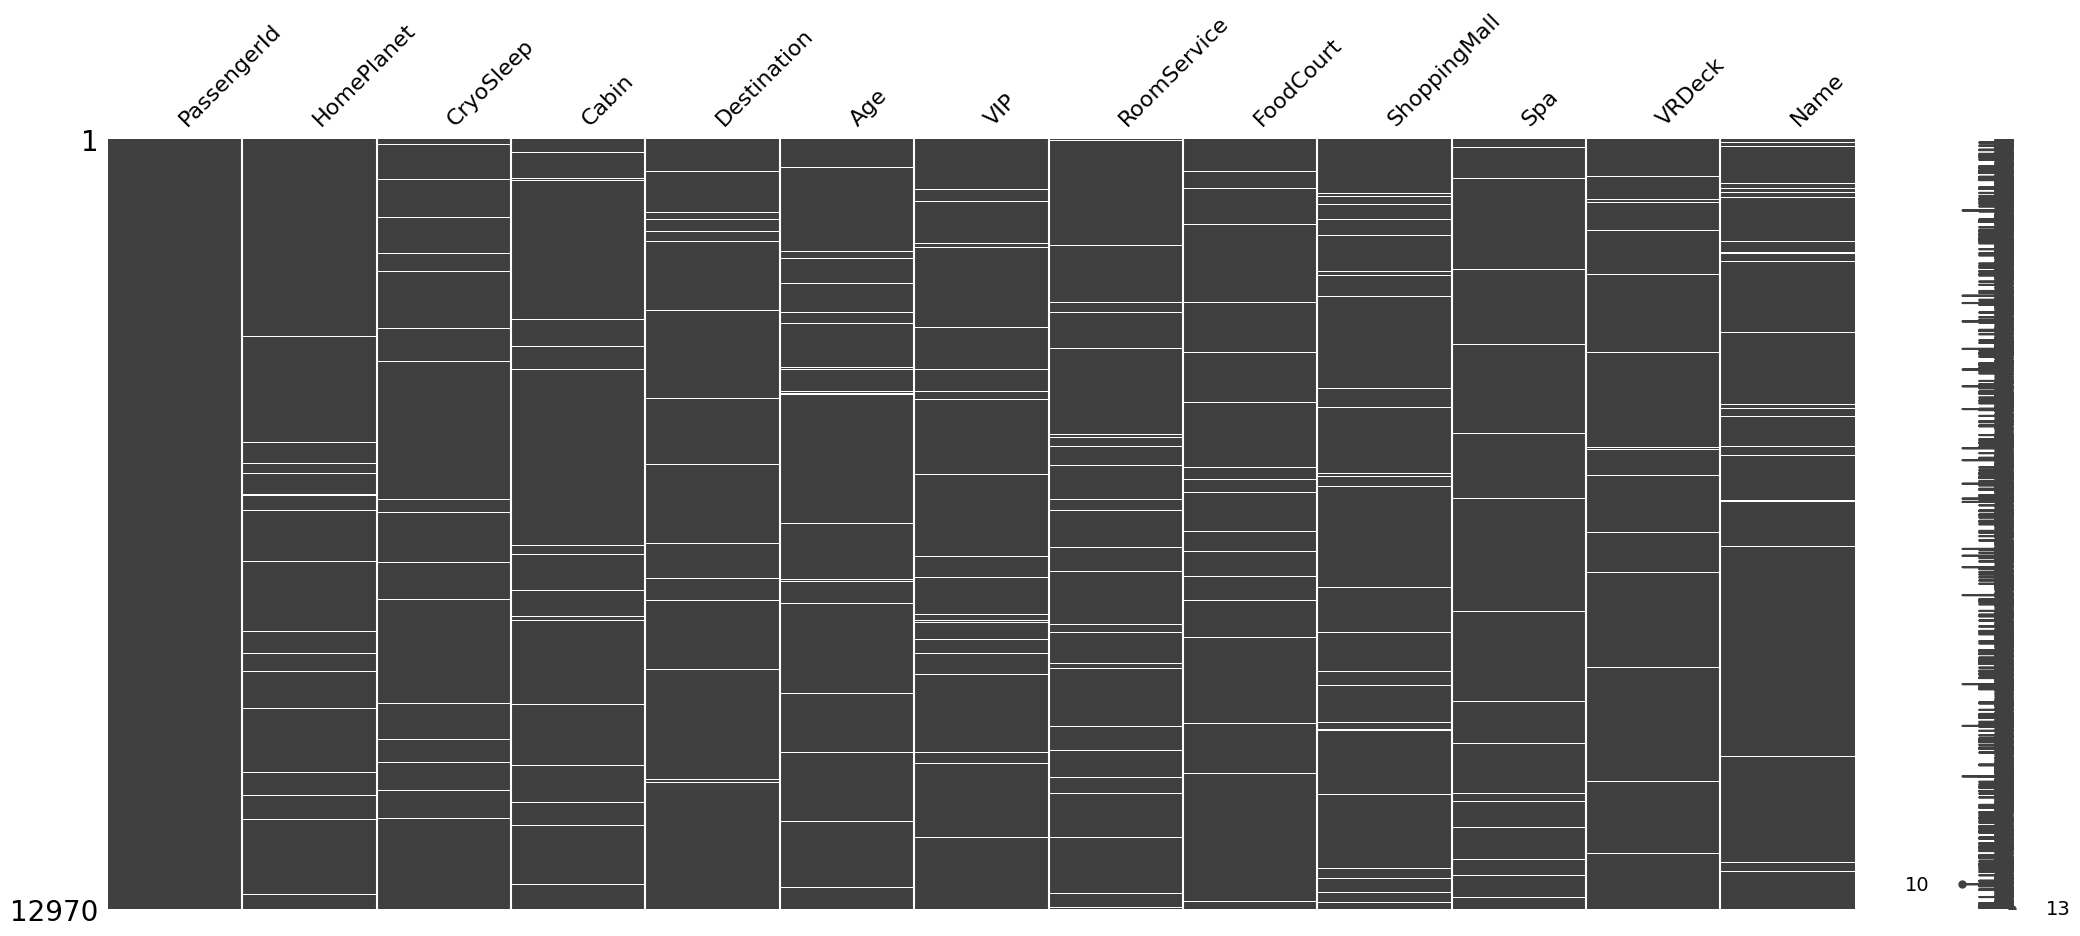

In [11]:
msno.matrix(data)

In [12]:
for c in data.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values))

PassengerId : 0
HomePlanet : 288
CryoSleep : 310
Cabin : 299
Destination : 274
Age : 270
VIP : 296
RoomService : 263
FoodCourt : 289
ShoppingMall : 306
Spa : 284
VRDeck : 268
Name : 294


<Axes: >

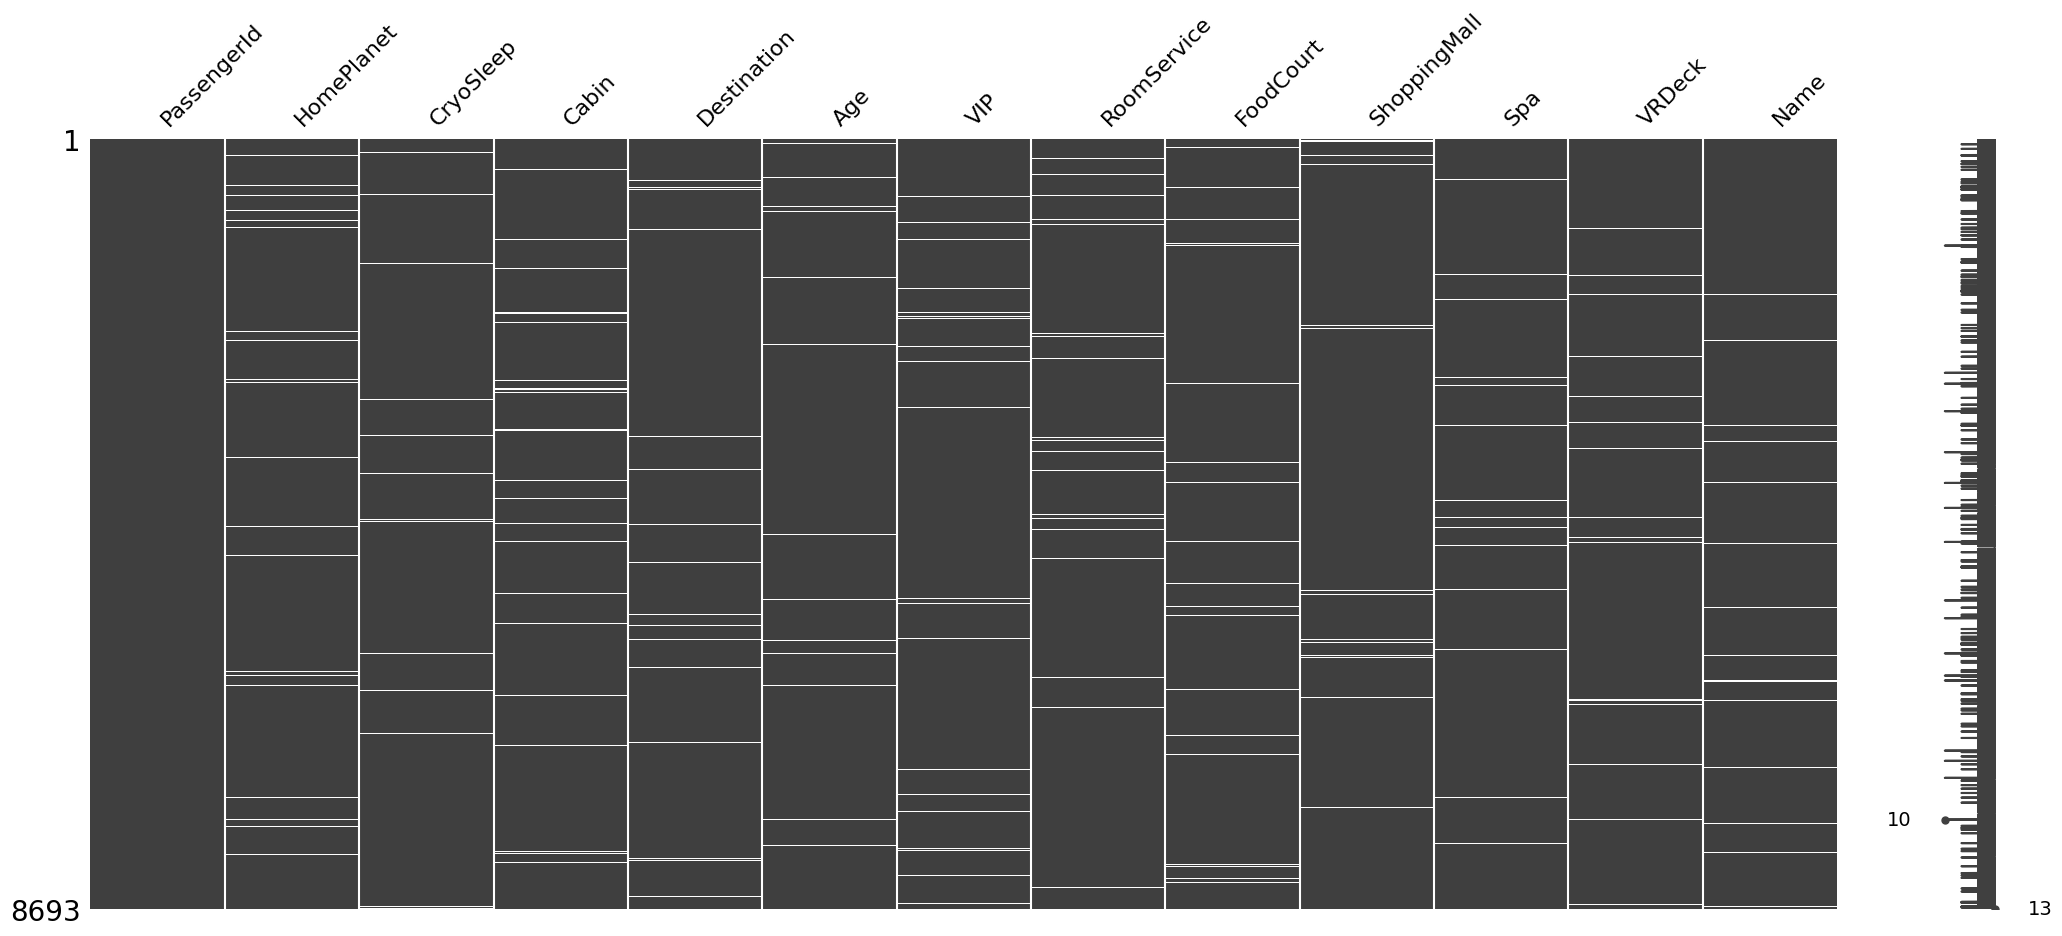

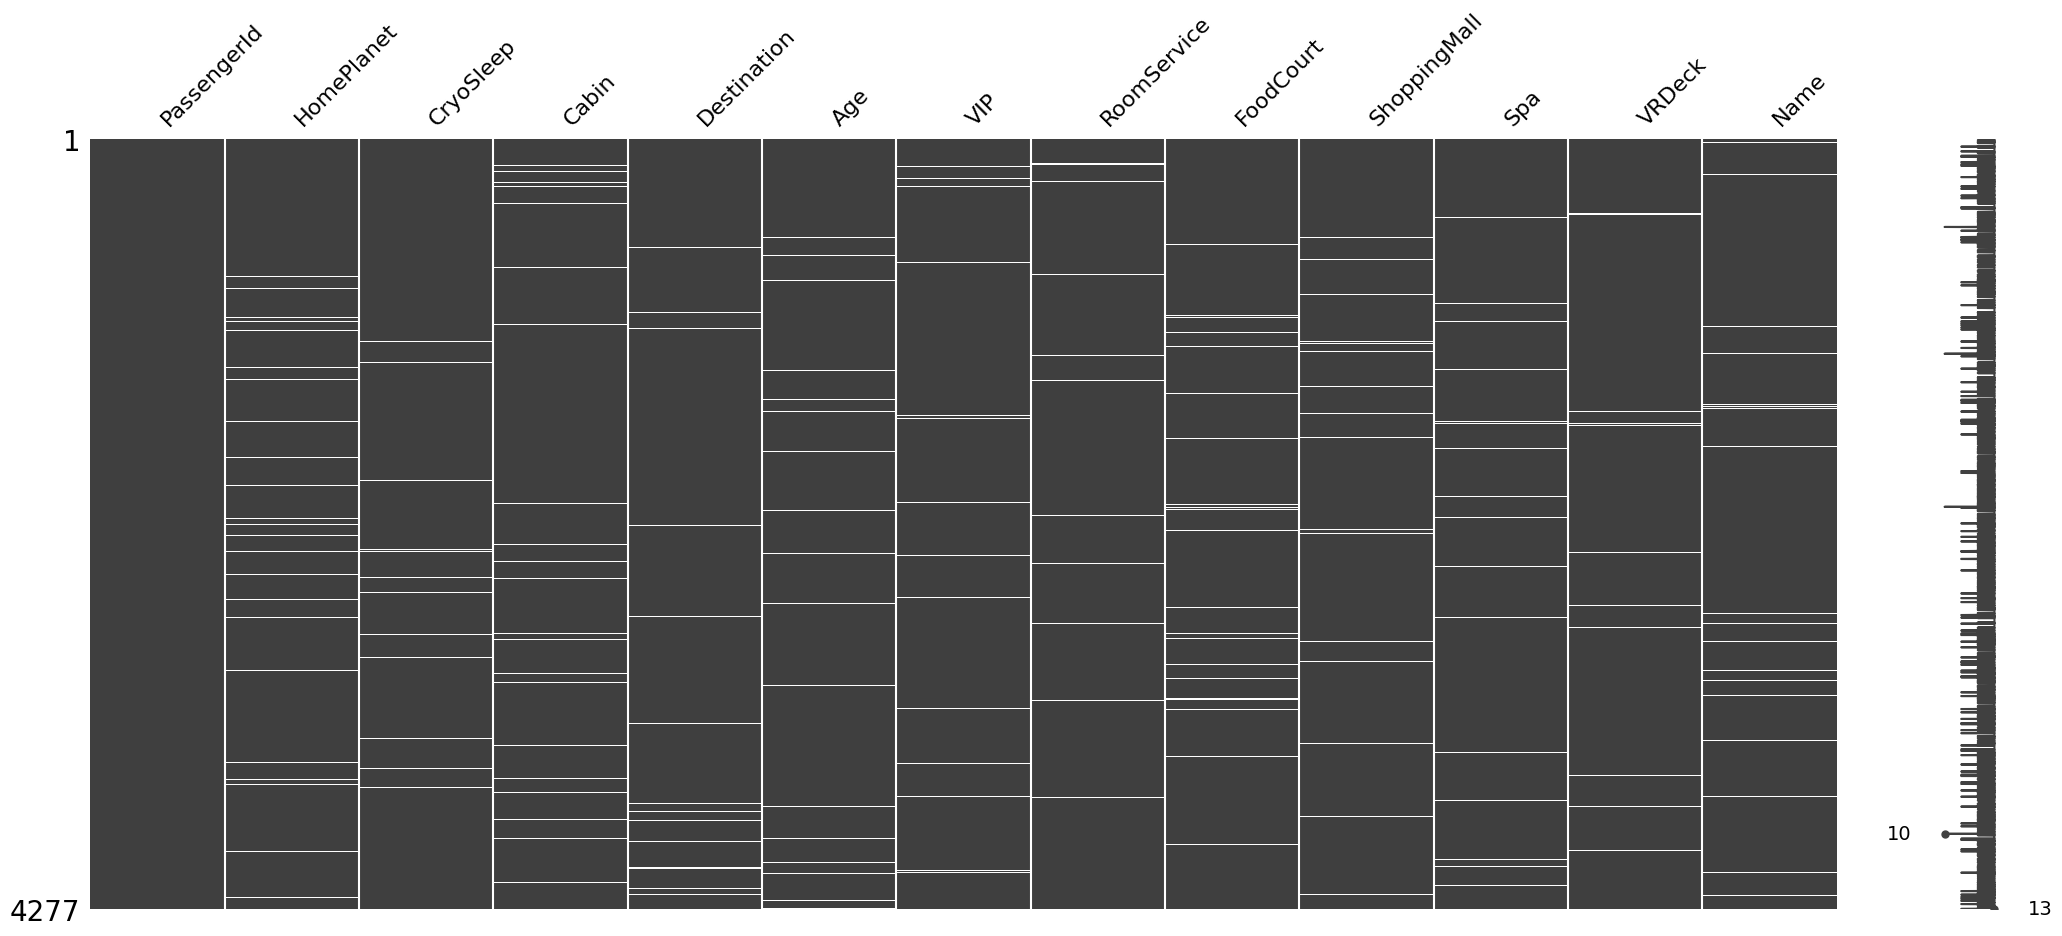

In [13]:
#결측치가 많아서 학습용, 테스터용 데이터를 각각 따로 확인
msno.matrix(train)
msno.matrix(test)

### 2-4. 데이터 분리
PassengerID나 Cabin 처럼 여러가지 정보가 조합된 코드는 단일한 내용으로 분리


In [14]:
# PassengerID를 그룹과 탑승순서로 분리

# 'Group' 분리: PassengerId 앞의 4글자 추출
data['Group'] = data['PassengerId'].str[:4]

# 'BoardingOrder' 분리: PassengerId 뒤 2글자 추출
data['BoardingOrder'] = data['PassengerId'].str[-2:]

# 결과 확인
data[['PassengerId', 'Group', 'BoardingOrder']].head()

,PassengerId,Group,BoardingOrder
0,0001_01,0001,01
1,0002_01,0002,01
2,0003_01,0003,01
3,0003_02,0003,02
4,0004_01,0004,01


In [15]:
# Cabin 데이터 확인
# '/'를 기준으로 분리하여 새로운 컬럼 생성
# 분리된 결과는 순서대로 Deck, CabinNum, CabinSide가 됩니다.
data[['Deck', 'CabinNum', 'CabinSide']] = data['Cabin'].str.split('/', expand=True)
# 결과 확인
data[['Cabin', 'Deck', 'CabinNum', 'CabinSide']].head()

,Cabin,Deck,CabinNum,CabinSide
0,B/0/P,B,0,P
1,F/0/S,F,0,S
2,A/0/S,A,0,S
3,A/0/S,A,0,S
4,F/1/S,F,1,S


In [16]:
#정규화할 세로운 데이터프레임 만들어주기
# 1. 추출할 컬럼 리스트 정의
# (이미 Deck, CabinNum, CabinSide 등이 분리되어 있다고 가정합니다)
selected_columns = [
    'Group', 'BoardingOrder', 'HomePlanet', 'CryoSleep',
    'Deck', 'CabinNum', 'CabinSide', 'Destination',
    'Age', 'VIP', 'RoomService', 'FoodCourt',
    'ShoppingMall', 'Spa', 'VRDeck', 'Name'
]

# 2. 데이터프레임 생성
# 원본 데이터(data)에서 해당 컬럼만 복사하여 df_norm에 할당합니다.
df_norm = data[selected_columns].copy()

# 3. 결과 확인
print("=== df_norm 컬럼 추출 완료 ===")
print(f"데이터 크기: {df_norm.shape}")
print(df_norm.columns)
display(df_norm.head())

=== df_norm 컬럼 추출 완료 ===
데이터 크기: (12970, 16)
Index(['Group', 'BoardingOrder', 'HomePlanet', 'CryoSleep', 'Deck', 'CabinNum',
       'CabinSide', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt',
       'ShoppingMall', 'Spa', 'VRDeck', 'Name'],
      dtype='object')


,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001,01,Europa,False,B,0,P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002,01,Earth,False,F,0,S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines
2,0003,01,Europa,False,A,0,S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent
3,0003,02,Europa,False,A,0,S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent
4,0004,01,Earth,False,F,1,S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines


In [17]:
# 결측치 다시 확인
for c in df_norm.columns:
    print('{} : {}'.format(c, len(data.loc[pd.isnull(data[c]), c].values)))

Group : 0
BoardingOrder : 0
HomePlanet : 288
CryoSleep : 310
Deck : 299
CabinNum : 299
CabinSide : 299
Destination : 274
Age : 270
VIP : 296
RoomService : 263
FoodCourt : 289
ShoppingMall : 306
Spa : 284
VRDeck : 268
Name : 294


### 2-5. 전략세우기
 * 모든 데이터가 다 있는 것은 오로지 PassengerID뿐.
 * PassengerID는 그룹과 탑승순서의 조합이며
 보통 한 그룹은 가족단위이다.
 따라서, 그룹이 같으면 최소한 탑승지, 행성지등이 같을 것이라 예측할 수 있다.
* CryoSleep와 VIP여부등 같은 그룹에서도 개개인별로 달라지는 정보들이 있다. 이경우에는 컬럼별 확륙에 기반하여 값을 채우든지, 연계된 정보를 이용하여 채울 수 있다.
* 상식적으로 동면에 든 사람은 돈을 쓸 수 없으므로 Cryo Sleep이 Fale 이면 VIP나 ShoppingMall도 여전이 False 수 있다. (검증은 필요)

In [18]:
# 'Group'별로 묶어서 주요 컬럼들의 고유값(unique) 개수를 계산
# 고유값이 1이면 해당 그룹의 모든 멤버가 같은 값을 가짐을 의미
# Age- 승객의 나이,Name-이름은 당연히 각자 다르므로 제외.  VIP
group_uniques = df_norm.groupby('Group')[['HomePlanet', 'CryoSleep', 'Deck', 'CabinNum', 'CabinSide', 'Destination', 'VIP','RoomService']].nunique()

# 결과 확인 (상위 10개 그룹)
print(group_uniques.head(20))

       HomePlanet  CryoSleep  Deck  CabinNum  CabinSide  Destination  VIP  \
Group                                                                       
0001            1          1     1         1          1            1    1   
0002            1          1     1         1          1            1    1   
0003            1          1     1         1          1            1    2   
0004            1          1     1         1          1            1    1   
0005            1          1     1         1          1            1    1   
0006            1          2     2         2          1            1    1   
0007            1          1     1         1          1            1    1   
0008            1          2     1         1          1            2    1   
0009            1          1     1         1          1            1    1   
0010            1          1     1         1          1            1    1   
0011            1          1     1         1          1            1    1   

## 3. 데이터 분석하기

### 3-1. 그룹내 데이터 일치 가능성 높은 데이터부터 분석
#### (1) 출항지, 목적지, 그리고 Cabin 정보

In [19]:

cols_to_verify = ['HomePlanet', 'Destination', 'Deck', 'CabinNum', 'CabinSide']

print("=== 그룹 내 데이터 불일치 분석 (NaN 제외, 순수 불일치 그룹) ===\n")

for col in cols_to_verify:
    # 1. 그룹별로 NaN을 제외한 유니크 값의 개수(nunique) 계산
    # nunique()는 기본적으로 NaN을 카운트하지 않습니다.
    unique_counts = df_norm.groupby('Group')[col].nunique()

    # 2. 그룹별로 해당 컬럼에 NaN이 하나라도 있는지 확인
    has_nan = df_norm.groupby('Group')[col].apply(lambda x: x.isnull().any())

    # 3. 조건: 유니크 값이 2개 이상 '이면서' 결측치(NaN)는 '없어야' 함
    # (결측치가 있는 그룹은 나중에 보완 대상이므로 여기서 제외)
    mismatch_no_nan = (unique_counts >= 2) & (~has_nan)

    target_groups = mismatch_no_nan[mismatch_no_nan].index
    count = len(target_groups)
    total_groups = df_norm['Group'].nunique()

    print(f"[{col}]")
    print(f"  - 불일치 그룹 수: {count}개 (전체 그룹의 {count/total_groups:.2%})")

    if count > 0:
        # 실제 어떤 값이 섞여 있는지 상위 2개 예시
        examples = df_norm[df_norm['Group'].isin(target_groups)].groupby('Group')[col].unique().head(2)
        print(f"  - 불일치 예시: {examples.to_dict()}")
    else:
        print("  - 모든 그룹이 일치하거나 결측치를 포함하고 있습니다.")
    print("-" * 50)

=== 그룹 내 데이터 불일치 분석 (NaN 제외, 순수 불일치 그룹) ===

[HomePlanet]
  - 불일치 그룹 수: 0개 (전체 그룹의 0.00%)
  - 모든 그룹이 일치하거나 결측치를 포함하고 있습니다.
--------------------------------------------------
[Destination]
  - 불일치 그룹 수: 1033개 (전체 그룹의 11.13%)
  - 불일치 예시: {'0008': array(['55 Cancri e', 'TRAPPIST-1e'], dtype=object), '0017': array(['TRAPPIST-1e', '55 Cancri e'], dtype=object)}
--------------------------------------------------
[Deck]
  - 불일치 그룹 수: 654개 (전체 그룹의 7.05%)
  - 불일치 예시: {'0006': array(['F', 'G'], dtype=object), '0017': array(['G', 'F'], dtype=object)}
--------------------------------------------------
[CabinNum]
  - 불일치 그룹 수: 652개 (전체 그룹의 7.03%)
  - 불일치 예시: {'0006': array(['2', '0'], dtype=object), '0017': array(['0', '6'], dtype=object)}
--------------------------------------------------
[CabinSide]
  - 불일치 그룹 수: 0개 (전체 그룹의 0.00%)
  - 모든 그룹이 일치하거나 결측치를 포함하고 있습니다.
--------------------------------------------------


In [20]:
# 그룹내 일관성을 확인한 HomePlanet과 CabinSide의 결측치를 같은 그룹원의 다른 데이터를 확인하고 입력
cols_to_fill = ['HomePlanet', 'CabinSide']

for col in cols_to_fill:
    # 1. 그룹별로 가장 많이 등장하는 값(또는 유일한 값)으로 빈칸 채우기
    # transform(first)는 그룹 내의 첫 번째 유효한 값을 가져와서 모든 행에 뿌려줍니다.
    df_norm[col] = df_norm[col].fillna(df_norm.groupby('Group')[col].transform('first'))

# 보정 후 남아있는 결측치 확인
print("--- 보정 후 남은 결측치 수 ---")
print(df_norm[cols_to_fill].isnull().sum())

--- 보정 후 남은 결측치 수 ---
HomePlanet    157
CabinSide     162
dtype: int64


캐빈사이드안에 몇개의 덱이 있고 몇개의 룸이 있는지 확인하면 좋을꺼 같아. 최소한 결측치가 어느쪽 사이드, 어느 덱일 확률이 높은지 확인가능하지 않을까? 더불어 가족이라면 같은 덱에 빈 방을 룸넘버를 배정할 수 있지 않을까?  
  
#### (2) 사이드 및 덱별 객실/방 번호 분포 확인

In [21]:
# 1. Side별로 Deck의 유니크한 값과 개수 추출
side_deck_info = df_norm.groupby('CabinSide')['Deck'].agg(['nunique', 'unique']).reset_index()

print(side_deck_info)

  CabinSide  nunique                         unique
0         P        8  [B, F, G, D, C, nan, A, E, T]
1         S        8  [F, A, G, E, C, D, B, nan, T]


In [22]:
# 1. Side와 Deck을 결합한 새로운 임시 컬럼 생성 (분석용)
df_norm['Side_Deck'] = df_norm['CabinSide'] + '-' + df_norm['Deck']

# 2. Side_Deck별 유니크한 방 번호(CabinNum) 개수 집계
side_deck_stats = df_norm.groupby('Side_Deck')['CabinNum'].nunique().reset_index()
side_deck_stats.columns = ['Side_Deck', 'Unique_Rooms']

# 3. 결과 출력 (보기 좋게 정렬)
print("=== Side-Deck별 유니크 객실 수 ===")
print(side_deck_stats.sort_values(by='Side_Deck'))

=== Side-Deck별 유니크 객실 수 ===
   Side_Deck  Unique_Rooms
0        P-A            98
1        P-B           297
2        P-C           308
3        P-D           289
4        P-E           581
5        P-F          1864
6        P-G          1483
7        P-T             5
8        S-A           110
9        S-B           350
10       S-C           334
11       S-D           273
12       S-E           600
13       S-F          1770
14       S-G          1459
15       S-T             4


#### (3) 양 사이드가 동일한 덱과 동일한 룸 넘버를 지닐꺼라 생각했을 때 각 사이드-덱별로 몇개의 룸이 누락되었는지 계산해서 새로운 컬럼에 넣기

In [23]:
# 1. Side와 Deck 분리
side_deck_stats['Side'] = side_deck_stats['Side_Deck'].str.split('-').str[0]
side_deck_stats['Deck'] = side_deck_stats['Side_Deck'].str.split('-').str[1]

# 2. 각 Deck별로 양 사이드 중 최댓값을 기준(Target)으로 설정
side_deck_stats['Max_Rooms'] = side_deck_stats.groupby('Deck')['Unique_Rooms'].transform('max')

# 3. 누락된 방 개수 계산 (기준값 - 현재값)
side_deck_stats['Missing_Rooms'] = side_deck_stats['Max_Rooms'] - side_deck_stats['Unique_Rooms']

# 4.전체 누락된 방의 합계 대비 각 구역의 비율 계산
total_missing = side_deck_stats['Missing_Rooms'].sum()
side_deck_stats['Missing_Probability'] = side_deck_stats['Missing_Rooms'] / total_missing

# 결과 출력
print(side_deck_stats[['Side_Deck', 'Unique_Rooms', 'Missing_Rooms', 'Missing_Probability']])

   Side_Deck  Unique_Rooms  Missing_Rooms  Missing_Probability
0        P-A            98             12             0.048980
1        P-B           297             53             0.216327
2        P-C           308             26             0.106122
3        P-D           289              0             0.000000
4        P-E           581             19             0.077551
5        P-F          1864              0             0.000000
6        P-G          1483              0             0.000000
7        P-T             5              0             0.000000
8        S-A           110              0             0.000000
9        S-B           350              0             0.000000
10       S-C           334              0             0.000000
11       S-D           273             16             0.065306
12       S-E           600              0             0.000000
13       S-F          1770             94             0.383673
14       S-G          1459             24             0

#### (4) 출항지인경우 기존 데이터를 확인해서 비율적으로 결측치를 보완하기 위해 유니크한 출항지의 값의 비율을 계산

In [24]:
# 1. 출항지 고유값 갯수
hp_nunique = df_norm['HomePlanet'].nunique()

# 2. 출항지 리스트 만들기 (결측치 제외)
hp_list = df_norm['HomePlanet'].dropna().unique().tolist()

# 3. 출항지 정보가 Nan이 아닌 승객 수 (출항지별 카운트)
hp_counts = df_norm['HomePlanet'].value_counts()

# 4. 출항지 정보가 Nan이 아닌 승객 비율 계산
hp_ratio = data['HomePlanet'].value_counts(normalize=True)

# 결과 요약 출력
print(f"1. 출항지 고유값 갯수: {hp_nunique}개")
print(f"2. 출항지 리스트: {hp_list}")
print("-" * 30)
print("3 & 4. 출항지별 승객 수 및 비율 상세:")
hp_summary = pd.DataFrame({
    'Count': hp_counts,
    'Ratio': hp_ratio
})
print(hp_summary)

1. 출항지 고유값 갯수: 3개
2. 출항지 리스트: ['Europa', 'Earth', 'Mars']
------------------------------
3 & 4. 출항지별 승객 수 및 비율 상세:
            Count     Ratio
HomePlanet                 
Earth        6914  0.541318
Europa       3175  0.247043
Mars         2724  0.211639


#### (5) 목적지 비율 계산

In [25]:

# 1. 그룹 내 목적지 불일치 확률 계산 (NaN 제외)
# 목적지 정보가 2명 이상 있고 결측치가 없는 그룹 중, 목적지가 서로 다른 그룹의 비율
group_dest = df_norm.groupby('Group')['Destination'].agg(['nunique', 'count', lambda x: x.isnull().any()])
group_dest.columns = ['nunique', 'total_count', 'has_nan']

# 분석 대상: 멤버가 2명 이상이고 결측치가 없는 그룹
clean_groups = group_dest[(group_dest['total_count'] >= 2) & (group_dest['has_nan'] == False)]
mismatch_groups = clean_groups[clean_groups['nunique'] > 1]

mismatch_prob = len(mismatch_groups) / len(clean_groups) if len(clean_groups) > 0 else 0

# 2. 개인별 목적지 고유값 개수 (전체 데이터 기준)
dest_nunique = df_norm['Destination'].nunique()

# 3 & 4. 목적지 리스트, 승객 수 및 비율 계산 (NaN 제외)
dest_counts = df_norm['Destination'].value_counts()
dest_ratio = df_norm['Destination'].value_counts(normalize=True)

# 결과 출력
print(f"=== [1] 그룹 내 일관성 분석 ===")
print(f"  - 분석 대상 그룹 수 (멤버 2인 이상, 결측치 없음): {len(clean_groups)}개")
print(f"  - 목적지가 갈리는 그룹 수: {len(mismatch_groups)}개")
print(f"  - 그룹 내 목적지가 다를 확률: {mismatch_prob:.2%}")
print("\n=== [2] 고유값 정보 ===")
print(f"  - 목적지 고유값 개수: {dest_nunique}개")
print(f"  - 목적지 종류: {dest_counts.index.tolist()}")
print("\n=== [3 & 4] 목적지별 승객 수 및 비율 ===")
dest_summary = pd.DataFrame({
    'Passenger_Count': dest_counts,
    'Ratio': dest_ratio.map(lambda x: f"{x:.2%}")
})
print(dest_summary)

=== [1] 그룹 내 일관성 분석 ===
  - 분석 대상 그룹 수 (멤버 2인 이상, 결측치 없음): 2015개
  - 목적지가 갈리는 그룹 수: 1033개
  - 그룹 내 목적지가 다를 확률: 51.27%

=== [2] 고유값 정보 ===
  - 목적지 고유값 개수: 3개
  - 목적지 종류: ['TRAPPIST-1e', '55 Cancri e', 'PSO J318.5-22']

=== [3 & 4] 목적지별 승객 수 및 비율 ===
               Passenger_Count   Ratio
Destination                           
TRAPPIST-1e               8871  69.87%
55 Cancri e               2641  20.80%
PSO J318.5-22             1184   9.33%


그룹원과 목적지가 같은 확률이 48.73%이고 다른 두행성중 하나일 확률은 51.27% 남은 행성이 뭐냐에 따라 달라질꺼 같아. 기존 개산 비율은 개별 승객일 경우로 하고 그룹내 목적지가 'TRAPPIST-1e', '55 Cancri e', 'PSO J318.5-22' 경우 각각 목적지가 될 가중치 비율을 계산

In [26]:

# 1. 멤버가 2명 이상인 그룹의 데이터만 추출
group_sizes = df_norm.groupby('Group').size()
multi_member_groups = group_sizes[group_sizes >= 2].index
df_multi = df_norm[data['Group'].isin(multi_member_groups)].copy()

# 2. 분석을 위한 가중치 매트릭스 초기화
dest_list = ['TRAPPIST-1e', '55 Cancri e', 'PSO J318.5-22']
weights = pd.DataFrame(0, index=dest_list, columns=dest_list)

# 3. 그룹별로 순회하며 목적지 쌍(Pair) 빈도 계산
for _, group_df in df_multi.groupby('Group'):
    dests = group_df['Destination'].dropna().unique()
    if len(dests) > 0:
        for d1 in dests:
            for d2 in group_df['Destination'].dropna():
                weights.loc[d1, d2] += 1

# 4. 행별로 합계가 1이 되도록 정규화 (가중치 비율 산출)
dest_weights = weights.div(weights.sum(axis=1), axis=0)

print("=== 그룹 내 목적지 존재 시 타겟 목적지 가중치 (Destination Weights) ===")
display(dest_weights)

=== 그룹 내 목적지 존재 시 타겟 목적지 가중치 (Destination Weights) ===


,TRAPPIST-1e,55 Cancri e,PSO J318.5-22
TRAPPIST-1e,0.739499,0.203617,0.056885
55 Cancri e,0.486379,0.470100,0.043522
PSO J318.5-22,0.495030,0.143141,0.361829


### 3-2. 그룹이여도 개개이별 다를 가능성이 높은 데이터 분석

In [27]:
# CryoSleep, VIP는 True와 False값을 지님. 같은 가족이라도 개개인 별로 다를 수 있는지 확인
target_cols = ['CryoSleep', 'VIP']

for col in target_cols:
    # 1. 그룹별 고유값 개수 확인 (NaN 제외)
    nunique_counts = df_norm.groupby('Group')[col].nunique()

    # 2. 고유값이 정확히 2개인 그룹(즉, True와 False가 섞인 그룹) 추출
    mixed_groups = nunique_counts[nunique_counts == 2].index

    print(f"[{col}]")
    print(f"  - True와 False가 섞여 있는 그룹 수: {len(mixed_groups)}개")

    if len(mixed_groups) > 0:
        # 실제 어떤 식으로 섞여 있는지 상위 3개 그룹 예시 출력
        example = df_norm[df_norm['Group'].isin(mixed_groups)].groupby('Group')[col].unique().head(3)
        print(f"  - 예시 그룹별 값: \n{example.to_dict()}")
    print("-" * 50)

[CryoSleep]
  - True와 False가 섞여 있는 그룹 수: 1230개
  - 예시 그룹별 값: 
{'0006': array([False, True], dtype=object), '0008': array([True, False], dtype=object), '0020': array([True, False], dtype=object)}
--------------------------------------------------
[VIP]
  - True와 False가 섞여 있는 그룹 수: 146개
  - 예시 그룹별 값: 
{'0003': array([True, False], dtype=object), '0128': array([True, False], dtype=object), '0194': array([False, True], dtype=object)}
--------------------------------------------------


#### (1) 상식적으로 동면에 들어간 사람은 돈을 못쓴다.     
CryoSleep 인 사람이 VIP가 False 확률 RoomService	FoodCourt	ShoppingMall	Spa	VRDeck 에서 돈쓴게 0일 확률이 높다. 확인 좀

In [28]:
# 1. 지출 관련 컬럼 리스트 정의
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. CryoSleep이 True인 승객 데이터만 추출
cryo_true = df_norm[df_norm['CryoSleep'] == True].copy()

# 3. 각 지출 항목이 0원인 승객의 비율 계산
print("=== CryoSleep 승객의 지출 0원 확률 분석 ===")
for col in exp_cols:
    zero_count = (cryo_true[col] == 0).sum()
    total_count = len(cryo_true)
    # 결측치를 제외한 실제 데이터 중 0원인 비율
    valid_count = cryo_true[col].dropna().count()
    zero_ratio = (cryo_true[cryo_true[col].notnull()][col] == 0).mean()

    print(f"[{col}]")
    print(f"  - 0원 지출 승객: {zero_count}명 / 실제 데이터: {valid_count}명")
    print(f"  - 0원일 확률: {zero_ratio:.2%}")

# 4. VIP가 False일 확률 분석
vip_false_ratio = (cryo_true['VIP'] == False).mean()
print(f"\n[VIP Status]")
print(f"  - VIP가 False일 확률: {vip_false_ratio:.2%}")

# 5. 모든 지출 항목의 합계가 0원인지 확인
cryo_true['TotalExp'] = cryo_true[exp_cols].sum(axis=1)
total_zero_ratio = (cryo_true['TotalExp'] == 0).mean()
print(f"\n[Total Expenditure]")
print(f"  - 모든 지출 합계가 0원일 확률: {total_zero_ratio:.2%}")

=== CryoSleep 승객의 지출 0원 확률 분석 ===
[RoomService]
  - 0원 지출 승객: 4488명 / 실제 데이터: 4488명
  - 0원일 확률: 100.00%
[FoodCourt]
  - 0원 지출 승객: 4472명 / 실제 데이터: 4472명
  - 0원일 확률: 100.00%
[ShoppingMall]
  - 0원 지출 승객: 4450명 / 실제 데이터: 4450명
  - 0원일 확률: 100.00%
[Spa]
  - 0원 지출 승객: 4474명 / 실제 데이터: 4474명
  - 0원일 확률: 100.00%
[VRDeck]
  - 0원 지출 승객: 4490명 / 실제 데이터: 4490명
  - 0원일 확률: 100.00%

[VIP Status]
  - VIP가 False일 확률: 97.12%

[Total Expenditure]
  - 모든 지출 합계가 0원일 확률: 100.00%


In [29]:
# 1. 대상 컬럼 정의
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. CryoSleep이 False인 승객의 지출 항목 NaN을 0으로 채우기
# 깨어 있었지만 해당 서비스를 이용하지 않았다고 가정합니다.
for col in exp_cols:
    df_norm.loc[(df_norm['CryoSleep'] == False) & (df_norm[col].isnull()), col] = 0

# 3. CryoSleep이 False인 승객의 VIP NaN을 False로 채우기
# 앞서 분석한 대로 VIP 비율이 매우 낮으므로(약 3%) False로 채우는 것이 안전합니다.
df_norm.loc[(df_norm['CryoSleep'] == False) & (df_norm['VIP'].isnull()), 'VIP'] = False

# 4. 결과 확인
print("--- CryoSleep이 False인 승객의 결측치 처리 완료 ---")
print(df_norm.isnull().sum())

--- CryoSleep이 False인 승객의 결측치 처리 완료 ---
Group              0
BoardingOrder      0
HomePlanet       157
CryoSleep        310
Deck             299
CabinNum         299
CabinSide        162
Destination      274
Age              270
VIP              113
RoomService       96
FoodCourt        112
ShoppingMall     141
Spa              114
VRDeck            99
Name             294
Side_Deck        299
dtype: int64


### 3-3. 이제 CryoSleep 비율, CryoSleep가 아닌 개인이 VIP인 비율을 확인하기.

In [31]:
# 1. CryoSleep 비율 확인
cryo_ratio = df_norm['CryoSleep'].value_counts(normalize=True)
print("=== [1] 전체 승객 CryoSleep 비율 ===")
print(cryo_ratio.map(lambda x: f"{x:.2%}"))
print("-" * 30)

# 2. CryoSleep이 아닌(False) 승객 중 VIP 비율 확인
non_cryo_vip_ratio = df_norm[df_norm['CryoSleep'] == False]['VIP'].value_counts(normalize=True)
print("=== [2] 깨어 있는 승객(Non-CryoSleep) 중 VIP 비율 ===")
print(non_cryo_vip_ratio.map(lambda x: f"{x:.2%}"))
print("-" * 30)

=== [1] 전체 승객 CryoSleep 비율 ===
CryoSleep
False    63.82%
True     36.18%
Name: proportion, dtype: object
------------------------------
=== [2] 깨어 있는 승객(Non-CryoSleep) 중 VIP 비율 ===
VIP
False    97.04%
True      2.96%
Name: proportion, dtype: object
------------------------------


#### (1) 지출이 0인데 CryoSleep 값이 결측치인 사람도 있지 않을까? CryoSleep 아닌데 지출이 0인 사람 있는지 확인하기

In [32]:
# 1. 지출액 합계 재계산 (확인용)
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_norm['TotalExp'] = df_norm[exp_cols].sum(axis=1)

# 2. 조건: CryoSleep이 False인데 지출 합계가 0인 승객 추출
non_cryo_zero_exp = df_norm[(df_norm['CryoSleep'] == False) & (df_norm['TotalExp'] == 0)]

print(f"=== 깨어 있는 승객(CryoSleep=False) 중 지출 0원 분석 ===")
print(f"전체 인원: {len(non_cryo_zero_exp)}명")

# 3. 이들의 연령대 분포 확인 (매우 중요!)
print("\n[연령대별 분포]")
print(non_cryo_zero_exp['Age'].describe())

# 4. 13세 미만과 13세 이상으로 나누어 보기
under_13 = non_cryo_zero_exp[non_cryo_zero_exp['Age'] < 13]
over_13 = non_cryo_zero_exp[non_cryo_zero_exp['Age'] >= 13]

print(f"\n- 13세 미만(어린이): {len(under_13)}명")
print(f"- 13세 이상(청소년/성인): {len(over_13)}명")

=== 깨어 있는 승객(CryoSleep=False) 중 지출 0원 분석 ===
전체 인원: 740명

[연령대별 분포]
count    727.000000
mean      10.275103
std       12.872279
min        0.000000
25%        1.000000
50%        7.000000
75%       11.000000
max       71.000000
Name: Age, dtype: float64

- 13세 미만(어린이): 582명
- 13세 이상(청소년/성인): 145명


#### (2) 특정 덱에 살면 지출이 0일 확률이 높아질까?

=== Deck별 지출 0원 승객 비율 분석 ===


,Total_Passengers,Zero_Exp_Passengers,Zero_Exp_Ratio
Deck,,,
A,354,125.000000,35.31%
B,1141,683.000000,59.86%
C,1102,501.000000,45.46%
D,720,177.000000,24.58%
E,1323,340.000000,25.70%
F,4239,995.000000,23.47%
G,3781,2500.000000,66.12%
T,11,nan,nan%


/tmp/ipython-input-1881152674.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deck_analysis.index, y=deck_analysis['Zero_Exp_Ratio'], palette='viridis')


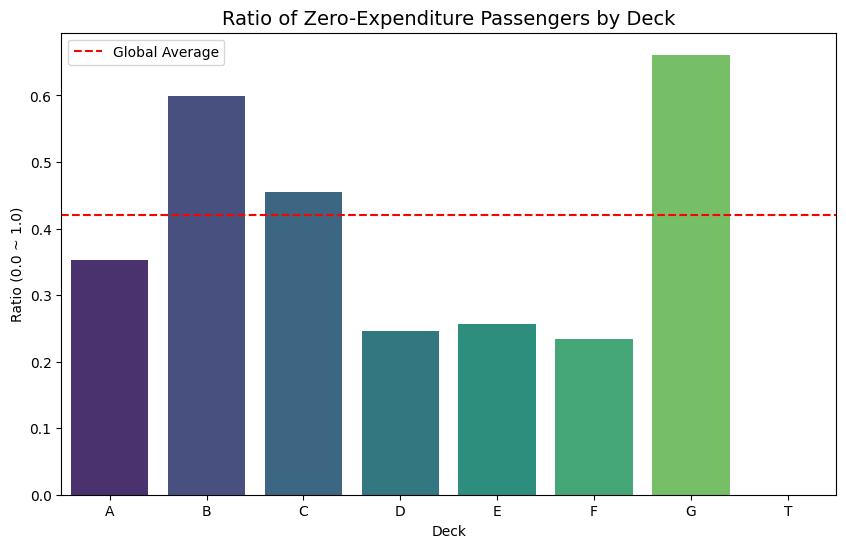

In [33]:
# 1. 지출 합계 계산 (이미 있다면 생략 가능)
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_norm['TotalExp'] = df_norm[exp_cols].sum(axis=1)

# 2. 지출이 0원인 승객 데이터만 추출
zero_exp_data = df_norm[df_norm['TotalExp'] == 0]

# 3. Deck별 전체 승객 수 vs 지출 0원 승객 수 비교
deck_total = df_norm['Deck'].value_counts()
deck_zero_exp = zero_exp_data['Deck'].value_counts()

# 4. 비율 계산 및 데이터프레임 정리
deck_analysis = pd.DataFrame({
    'Total_Passengers': deck_total,
    'Zero_Exp_Passengers': deck_zero_exp,
    'Zero_Exp_Ratio': (deck_zero_exp / deck_total)
}).sort_index()

print("=== Deck별 지출 0원 승객 비율 분석 ===")
display(deck_analysis.style.format({'Zero_Exp_Ratio': '{:.2%}'}))

# 5. 시각화 (비율 그래프)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=deck_analysis.index, y=deck_analysis['Zero_Exp_Ratio'], palette='viridis')
plt.title('Ratio of Zero-Expenditure Passengers by Deck', fontsize=14)
plt.ylabel('Ratio (0.0 ~ 1.0)')
plt.axhline(df_norm['TotalExp'].value_counts(normalize=True)[0], color='red', linestyle='--', label='Global Average')
plt.legend()
plt.show()

#### (4) 어린이 제외하고 동면중인 사람 제외하고 청소년.성인만 덱별로 지출 현황 다시 분석

=== [청소년/성인 & 비동면자] 덱별 지출 분석 결과 ===


,Avg_Spending,Total_Count,Zero_Exp_Count,Zero_Exp_Ratio
Deck,,,,
C,"$7,227.49",585,6,1.03%
B,"$6,800.52",471,40,8.49%
T,"$6,130.10",10,0,0.00%
A,"$4,980.32",229,11,4.80%
D,"$3,089.50",531,4,0.75%
E,"$1,716.92",994,52,5.23%
F,"$1,287.95",3122,6,0.19%
G,"$1,092.74",1247,23,1.84%


/tmp/ipython-input-3483543343.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deck_stats.index, y=deck_stats['Avg_Spending'], palette='coolwarm')


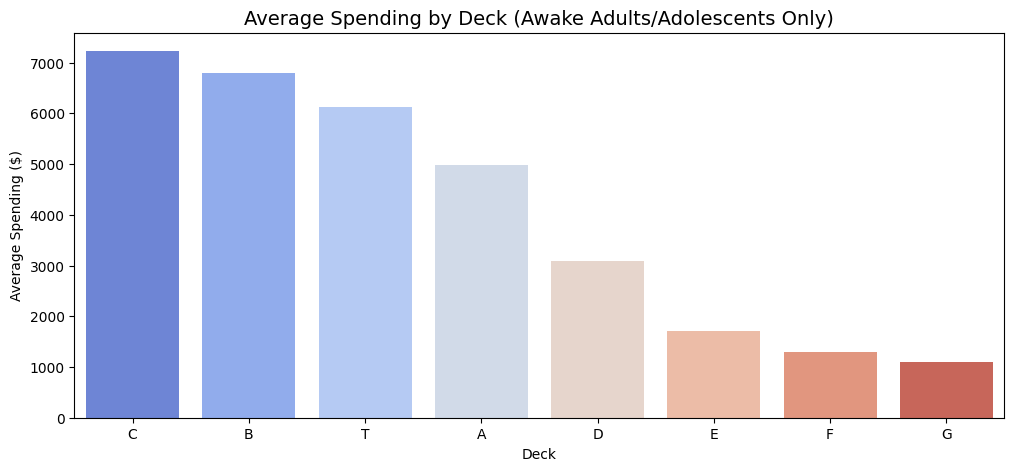

/tmp/ipython-input-3483543343.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=deck_stats.index, y=deck_stats['Zero_Exp_Ratio'], palette='viridis')


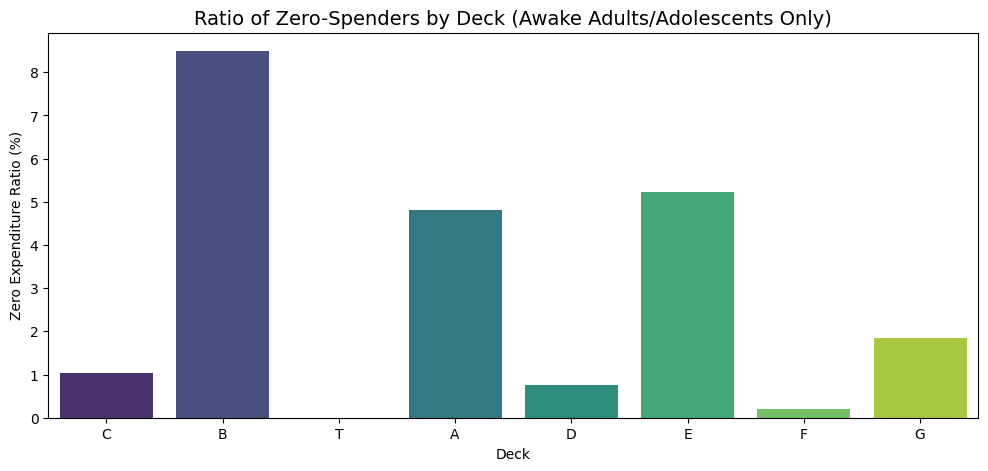

In [34]:
# 1. 대상 필터링: 청소년/성인(13세 이상) + 깨어 있는 사람(CryoSleep == False)
active_adults = df_norm[(df_norm['Age'] >= 13) & (df_norm['CryoSleep'] == False)].copy()

# 2. 덱별 평균 지출액 및 지출 0원 승객 비율 계산
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
active_adults['TotalExp'] = active_adults[exp_cols].sum(axis=1)

# 덱별 통계
deck_stats = active_adults.groupby('Deck').agg(
    Avg_Spending=('TotalExp', 'mean'),
    Total_Count=('TotalExp', 'count'),
    Zero_Exp_Count=('TotalExp', lambda x: (x == 0).sum())
)

deck_stats['Zero_Exp_Ratio'] = (deck_stats['Zero_Exp_Count'] / deck_stats['Total_Count']) * 100
deck_stats = deck_stats.sort_values(by='Avg_Spending', ascending=False)

print("=== [청소년/성인 & 비동면자] 덱별 지출 분석 결과 ===")
display(deck_stats.style.format({'Avg_Spending': '${:,.2f}', 'Zero_Exp_Ratio': '{:.2f}%'}))

# 3. 시각화: 덱별 평균 지출액
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.barplot(x=deck_stats.index, y=deck_stats['Avg_Spending'], palette='coolwarm')
plt.title('Average Spending by Deck (Awake Adults/Adolescents Only)', fontsize=14)
plt.ylabel('Average Spending ($)')
plt.show()

# 4. 시각화: 덱별 지출 0원 승객 비율
plt.figure(figsize=(12, 5))
sns.barplot(x=deck_stats.index, y=deck_stats['Zero_Exp_Ratio'], palette='viridis')
plt.title('Ratio of Zero-Spenders by Deck (Awake Adults/Adolescents Only)', fontsize=14)
plt.ylabel('Zero Expenditure Ratio (%)')
plt.show()

### 3-3.  각 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck'에서 돈을 얼마나쓸까?

#### (1) 소비값들 간의 상관계수 보기

=== 지출 항목 간 상관계수 표 ===


,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
RoomService,1.000000,-0.019647,0.054987,0.008570,-0.023130
FoodCourt,-0.019647,1.000000,-0.001744,0.226243,0.240978
ShoppingMall,0.054987,-0.001744,1.000000,0.011433,0.003102
Spa,0.008570,0.226243,0.011433,1.000000,0.145285
VRDeck,-0.023130,0.240978,0.003102,0.145285,1.000000


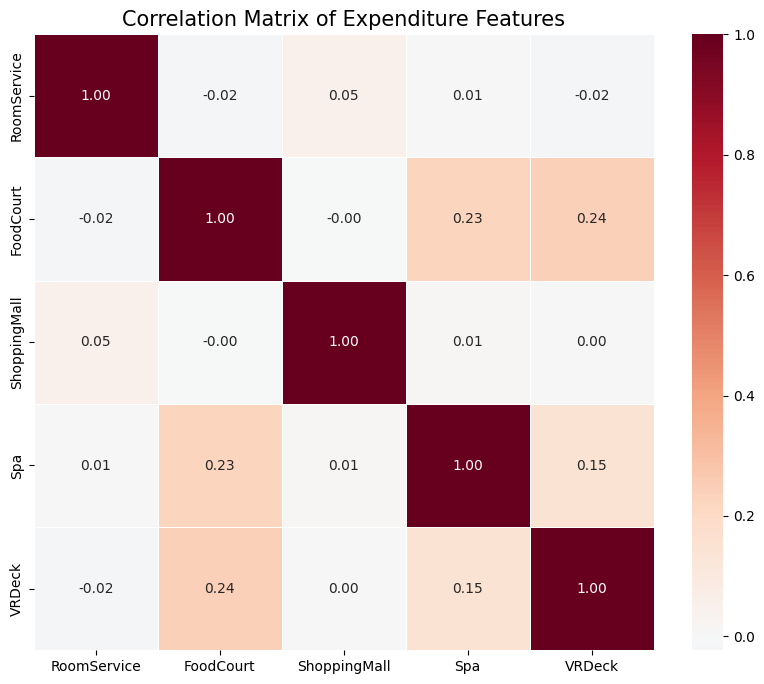

In [35]:
# 1. 분석할 지출 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 상관계수 계산 (결측치는 0으로 채우거나 제외하고 계산)
# 여기서는 지출이 없는 경우(0)를 포함하여 상관관계를 보는 것이 정확하므로 fillna(0)를 권장합니다.
correlation_matrix = data[exp_cols].fillna(0).corr()

# 3. 상관계수 표 출력
print("=== 지출 항목 간 상관계수 표 ===")
display(correlation_matrix)

# 4. 히트맵(Heatmap) 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Expenditure Features', fontsize=15)
plt.show()

#### (2) 1에 가까운 수가 없는게 정규화 하지 않아서 일수도 있기에 0과 1사이에 맞게 정규화하기

In [38]:
from sklearn.preprocessing import MinMaxScaler

# 1. 정규화할 대상 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 결측치 처리 (지출이 확인되지 않은 경우 0으로 간주)
df_norm[exp_cols] = df_norm[exp_cols].fillna(0)

# 3. MinMaxScaler 객체 생성
scaler = MinMaxScaler()

# 4. 정규화 수행 및 기존 컬럼에 덮어쓰기
# fit_transform은 각 컬럼의 최소값을 0, 최대값을 1로 변환합니다.
df_norm[exp_cols] = scaler.fit_transform(df_norm[exp_cols])

# 5. 결과 확인
print("=== 지출 컬럼 0~1 정규화 완료 ===")
display(df_norm[exp_cols].describe().loc[['min', 'max', 'mean']])

=== 지출 컬럼 0~1 정규화 완료 ===


,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
min,0.000000,0.000000,0.00000,0.000000,0.00000
max,1.000000,1.000000,1.00000,1.000000,1.00000
mean,0.015242,0.014822,0.00727,0.013465,0.01245


#### (3) 다시 상관계수 보기

=== 지출 항목 간 상관계수 표 ===


,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
RoomService,1.000000,-0.019647,0.054987,0.008570,-0.023130
FoodCourt,-0.019647,1.000000,-0.001744,0.226243,0.240978
ShoppingMall,0.054987,-0.001744,1.000000,0.011433,0.003102
Spa,0.008570,0.226243,0.011433,1.000000,0.145285
VRDeck,-0.023130,0.240978,0.003102,0.145285,1.000000


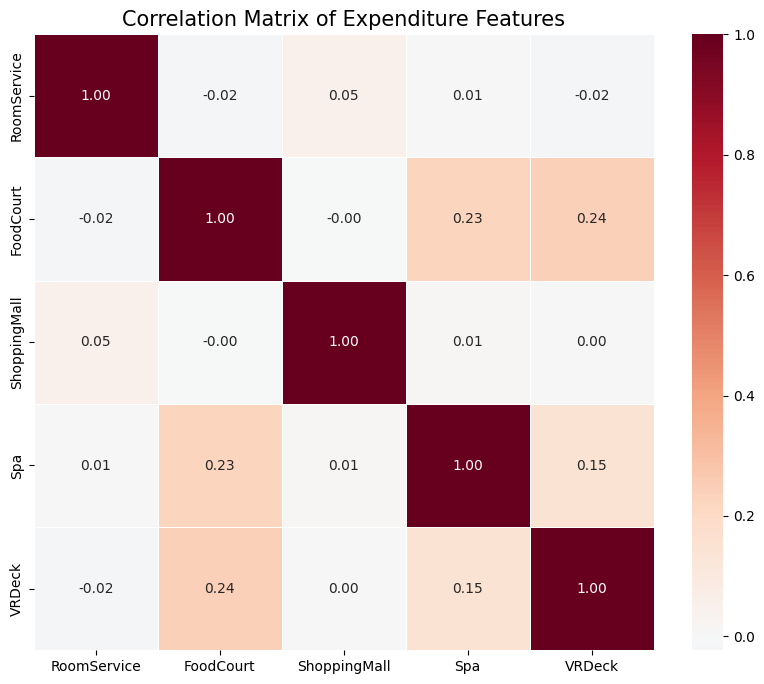

In [39]:
# 1. 분석할 지출 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 상관계수 계산 (결측치는 0으로 채우거나 제외하고 계산)
# 여기서는 지출이 없는 경우(0)를 포함하여 상관관계를 보는 것이 정확하므로 fillna(0)를 권장합니다.
correlation_matrix = data[exp_cols].fillna(0).corr()

# 3. 상관계수 표 출력
print("=== 지출 항목 간 상관계수 표 ===")
display(correlation_matrix)

# 4. 히트맵(Heatmap) 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Expenditure Features', fontsize=15)
plt.show()

#### (4) 소비값과 Age 간의 상간계수 보기

=== 나이(Age)와 지출 항목 간의 상관계수 ===
Age             1.000000
FoodCourt       0.122816
Spa             0.117427
VRDeck          0.100759
RoomService     0.067259
ShoppingMall    0.034632
Name: Age, dtype: float64


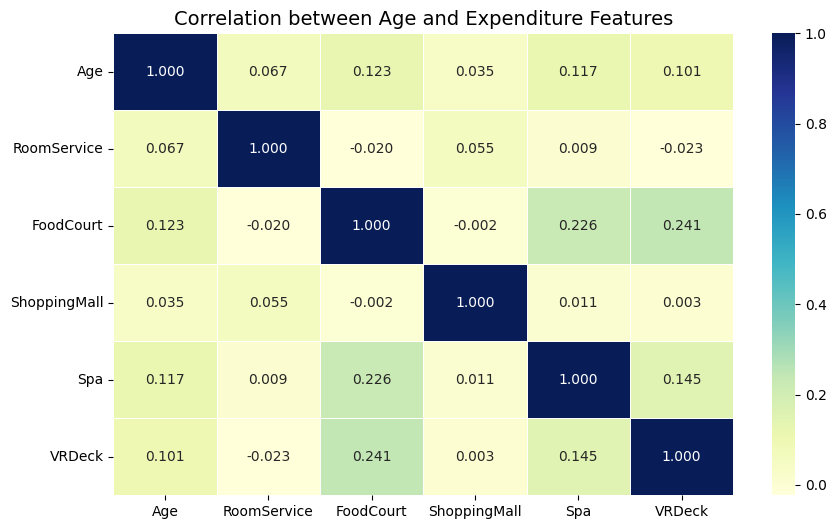

In [40]:
# 1. 분석할 컬럼 설정 (나이 + 지출 5개 항목)
age_exp_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 상관계수 계산 (결측치는 0으로 처리하거나 이미 처리된 df_norm 사용)
# df_norm에 Age가 포함되어 있으므로 바로 계산합니다.
age_exp_corr = df_norm[age_exp_cols].corr()

# 3. 나이(Age)와 다른 항목들 간의 상관계수만 따로 보기
print("=== 나이(Age)와 지출 항목 간의 상관계수 ===")
print(age_exp_corr['Age'].sort_values(ascending=False))

# 4. 히트맵 시각화 (선택 사항)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(age_exp_corr, annot=True, cmap='YlGnBu', fmt=".3f", linewidths=0.5)
plt.title('Correlation between Age and Expenditure Features', fontsize=14)
plt.show()

#### (5) 덱과 지출관계 상관계수 보기

=== 덱(Deck) 순서와 지출 간의 상관계수 ===
FoodCourt      -0.311034
VRDeck         -0.250804
Spa            -0.235197
ShoppingMall   -0.027409
RoomService    -0.027345
Deck_Num        1.000000
Name: Deck_Num, dtype: float64


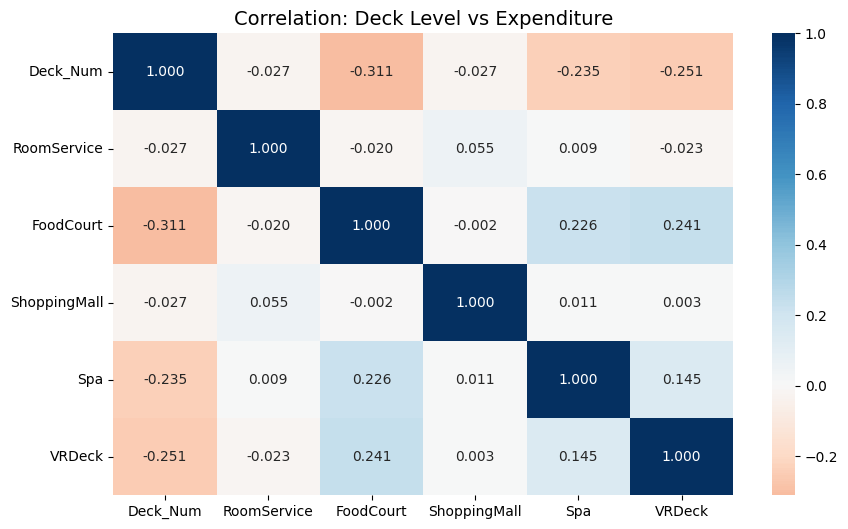

In [41]:
# 1. 덱(Deck)을 서열 숫자로 변환 (A가 가장 높고 T/G가 낮은 구조 가정)
# 분석을 위해 임시로 수치화된 컬럼을 만듭니다.
deck_mapping = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7, 'T': 8}
df_norm['Deck_Num'] = df_norm['Deck'].map(deck_mapping)

# 2. 분석할 컬럼 설정
deck_exp_cols = ['Deck_Num', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 3. 상관계수 계산
deck_corr = df_norm[deck_exp_cols].corr()

# 4. 덱 번호와 지출 간의 상관계수 출력
print("=== 덱(Deck) 순서와 지출 간의 상관계수 ===")
# 주의: Deck_Num이 커질수록(A->G) 낮은 등급을 의미하므로,
# 마이너스(-)가 나오면 상급 덱일수록 돈을 많이 쓴다는 뜻입니다.
print(deck_corr['Deck_Num'].sort_values())

# 5. 히트맵 시각화
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.heatmap(deck_corr, annot=True, cmap='RdBu', center=0, fmt=".3f")
plt.title('Correlation: Deck Level vs Expenditure', fontsize=14)
plt.show()

## 5. 범위형 값이 아닌 컬럼 One-Hot Encoding 하기

In [44]:
df_norm.head(3)

,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Side_Deck,TotalExp,Deck_Num
0,0001,01,Europa,False,B,0,P,TRAPPIST-1e,39.0,False,0.000000,0.000000,0.000000,0.00000,0.000000,Maham Ofracculy,P-B,0.0,2.0
1,0002,01,Earth,False,F,0,S,TRAPPIST-1e,24.0,False,0.007608,0.000302,0.001064,0.02450,0.001823,Juanna Vines,S-F,736.0,6.0
2,0003,01,Europa,False,A,0,S,TRAPPIST-1e,58.0,True,0.003001,0.119948,0.000000,0.29967,0.002030,Altark Susent,S-A,10383.0,1.0


#### (1) 출항지 원-핫인코딩하기

In [45]:

HomePlanet = pd.get_dummies(df_norm['HomePlanet'])
HomePlanet.head()
# pd.concat 함수로 데이터프레임 df_norm와 HomePlanet를 합치기
df_norm = pd.concat([df_norm, HomePlanet], axis=1)
df_norm.head()


,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,ShoppingMall,Spa,VRDeck,Name,Side_Deck,TotalExp,Deck_Num,Earth,Europa,Mars
0,0001,01,Europa,False,B,0,P,TRAPPIST-1e,39.0,False,...,0.000000,0.000000,0.000000,Maham Ofracculy,P-B,0.0,2.0,False,True,False
1,0002,01,Earth,False,F,0,S,TRAPPIST-1e,24.0,False,...,0.001064,0.024500,0.001823,Juanna Vines,S-F,736.0,6.0,True,False,False
2,0003,01,Europa,False,A,0,S,TRAPPIST-1e,58.0,True,...,0.000000,0.299670,0.002030,Altark Susent,S-A,10383.0,1.0,False,True,False
3,0003,02,Europa,False,A,0,S,TRAPPIST-1e,33.0,False,...,0.015793,0.148563,0.007997,Solam Susent,S-A,5176.0,1.0,False,True,False
4,0004,01,Earth,False,F,1,S,TRAPPIST-1e,16.0,False,...,0.006428,0.025214,0.000083,Willy Santantines,S-F,1091.0,6.0,True,False,False


#### (2) 목적지 원-핫 인코딩하기

In [46]:

Destination = pd.get_dummies(df_norm['Destination'])
Destination.head()
# pd.concat 함수로 데이터프레임 df_norm과 를 합치기
df_norm = pd.concat([df_norm, Destination], axis=1)
df_norm.head()


,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,Name,Side_Deck,TotalExp,Deck_Num,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
0,0001,01,Europa,False,B,0,P,TRAPPIST-1e,39.0,False,...,Maham Ofracculy,P-B,0.0,2.0,False,True,False,False,False,True
1,0002,01,Earth,False,F,0,S,TRAPPIST-1e,24.0,False,...,Juanna Vines,S-F,736.0,6.0,True,False,False,False,False,True
2,0003,01,Europa,False,A,0,S,TRAPPIST-1e,58.0,True,...,Altark Susent,S-A,10383.0,1.0,False,True,False,False,False,True
3,0003,02,Europa,False,A,0,S,TRAPPIST-1e,33.0,False,...,Solam Susent,S-A,5176.0,1.0,False,True,False,False,False,True
4,0004,01,Earth,False,F,1,S,TRAPPIST-1e,16.0,False,...,Willy Santantines,S-F,1091.0,6.0,True,False,False,False,False,True


#### (3) 캐빈 사이드 원핫인코딩하기

In [47]:

CabinSide = pd.get_dummies(df_norm['CabinSide'])
CabinSide.head()
# pd.concat 함수로 데이터프레임 df_norm과 를 합치기
df_norm = pd.concat([df_norm, CabinSide], axis=1)
df_norm.head()

,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,TotalExp,Deck_Num,Earth,Europa,Mars,55 Cancri e,PSO J318.5-22,TRAPPIST-1e,P,S
0,0001,01,Europa,False,B,0,P,TRAPPIST-1e,39.0,False,...,0.0,2.0,False,True,False,False,False,True,True,False
1,0002,01,Earth,False,F,0,S,TRAPPIST-1e,24.0,False,...,736.0,6.0,True,False,False,False,False,True,False,True
2,0003,01,Europa,False,A,0,S,TRAPPIST-1e,58.0,True,...,10383.0,1.0,False,True,False,False,False,True,False,True
3,0003,02,Europa,False,A,0,S,TRAPPIST-1e,33.0,False,...,5176.0,1.0,False,True,False,False,False,True,False,True
4,0004,01,Earth,False,F,1,S,TRAPPIST-1e,16.0,False,...,1091.0,6.0,True,False,False,False,False,True,False,True


#### (3) Deck 원핫인코딩하기

In [48]:

Deck = pd.get_dummies(df_norm['Deck'])
Deck.head()
# pd.concat 함수로 데이터프레임 df_norm과 를 합치기
df_norm = pd.concat([df_norm, Deck], axis=1)
df_norm.head()

,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,P,S,A,B,C,D,E,F,G,T
0,0001,01,Europa,False,B,0,P,TRAPPIST-1e,39.0,False,...,True,False,False,True,False,False,False,False,False,False
1,0002,01,Earth,False,F,0,S,TRAPPIST-1e,24.0,False,...,False,True,False,False,False,False,False,True,False,False
2,0003,01,Europa,False,A,0,S,TRAPPIST-1e,58.0,True,...,False,True,True,False,False,False,False,False,False,False
3,0003,02,Europa,False,A,0,S,TRAPPIST-1e,33.0,False,...,False,True,True,False,False,False,False,False,False,False
4,0004,01,Earth,False,F,1,S,TRAPPIST-1e,16.0,False,...,False,True,False,False,False,False,False,True,False,False


## 6. 결측치 다시한번 채워 넣기

### 이때는 몰랐지. 결측치를 먼저 채워놓고 정규화를 하는게 좋다는 걸... 섣부른 정규화 흔적

In [51]:
# 나이랑 VIP 값 정규화
# 1. 나이(Age) 정규화 (0~1 사이 값으로 변환)
# 결측치가 있다면 평균이나 중앙값으로 먼저 채우는 것이 좋습니다.
df_norm['Age'] = df_norm['Age'].fillna(df_norm['Age'].median())

scaler = MinMaxScaler()
df_norm['Age'] = scaler.fit_transform(df_norm[['Age']])

# 2. VIP를 bool(True/False) 값으로 변환
# 데이터가 문자열('False', 'True')이나 객체 타입인 경우를 대비해 처리합니다.
# 이미 결측치 처리를 하셨다면 바로 astype(bool)을 쓰면 됩니다.
df_norm['VIP'] = df_norm['VIP'].fillna(False).astype(bool)

# 3. 결과 확인
print("=== 정규화 및 타입 변환 완료 ===")
print(df_norm[['Age', 'VIP']].describe())
print(f"\nVIP 데이터 타입: {df_norm['VIP'].dtype}")
df_norm[['Age', 'VIP']].head()

=== 정규화 및 타입 변환 완료 ===
                Age
count  12970.000000
mean       0.363735
std        0.180240
min        0.000000
25%        0.253165
50%        0.341772
75%        0.468354
max        1.000000

VIP 데이터 타입: bool


/tmp/ipython-input-321426705.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_norm['VIP'] = df_norm['VIP'].fillna(False).astype(bool)


,Age,VIP
0,0.493671,False
1,0.303797,False
2,0.734177,True
3,0.417722,False
4,0.202532,False


### 6-1. 사이드 덱 정보로 결측치 채워 넣기

#### 목적지 및 Side_Deck 점유 비율 분석

=== [1] 목적지(Destination)별 승객 비율 ===
Destination
TRAPPIST-1e      69.87%
55 Cancri e      20.80%
PSO J318.5-22     9.33%
Name: proportion, dtype: object

=== [2] Side_Deck별 승객 비율 (상위 10개) ===
Side_Deck
P-F    17.19%
S-F    16.27%
S-G    14.96%
P-G    14.88%
S-E     5.38%
P-E     5.06%
S-B     4.96%
S-C     4.49%
P-C     4.21%
P-B     4.04%
Name: proportion, dtype: object


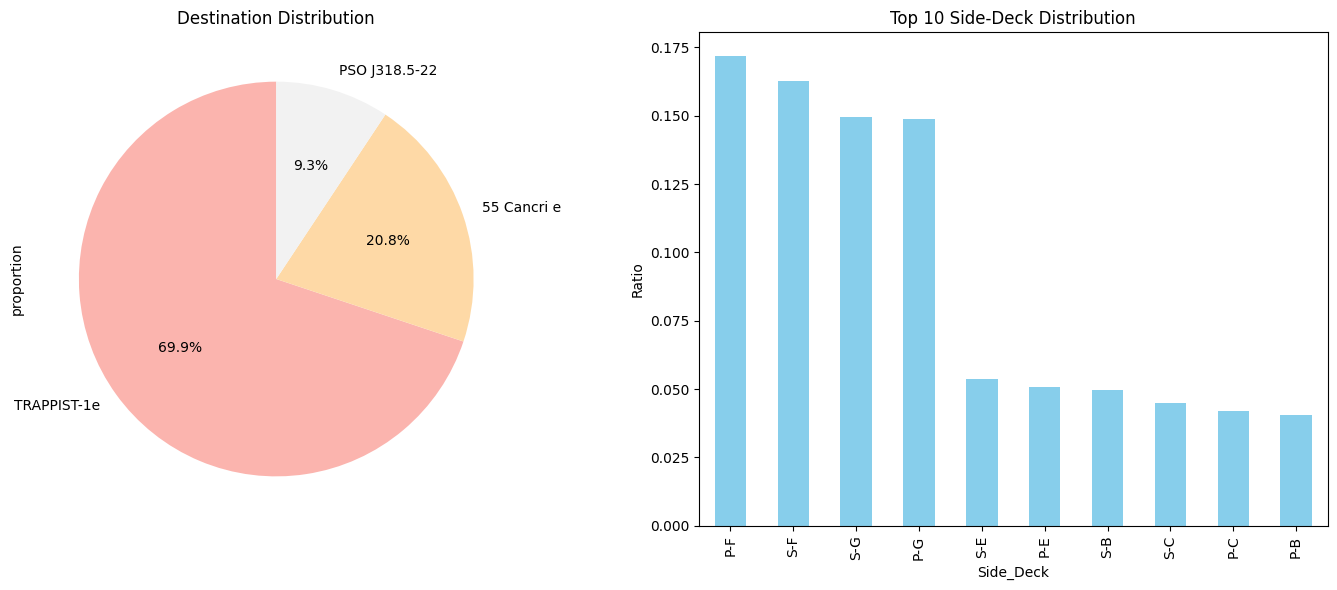

In [54]:
# 1. 목적지(Destination) 비율 계산
dest_ratio = df_norm['Destination'].value_counts(normalize=True)

# 2. Side_Deck 비율 계산
# (Side_Deck 컬럼이 아직 있다면 사용, 없다면 CabinSide와 Deck을 조합)
if 'Side_Deck' not in df_norm.columns:
    df_norm['Side_Deck'] = df_norm['CabinSide'].astype(str) + '-' + df_norm['Deck'].astype(str)

side_deck_ratio = df_norm['Side_Deck'].value_counts(normalize=True)

# 3. 결과 출력
print("=== [1] 목적지(Destination)별 승객 비율 ===")
print(dest_ratio.map(lambda x: f"{x:.2%}"))

print("\n=== [2] Side_Deck별 승객 비율 (상위 10개) ===")
print(side_deck_ratio.head(10).map(lambda x: f"{x:.2%}"))

# 시각화 (Pie Chart)
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# 목적지 비율 파이차트
plt.subplot(1, 2, 1)
dest_ratio.plot.pie(autopct='%.1f%%', startangle=90, cmap='Pastel1')
plt.title('Destination Distribution')

# Side_Deck 비율 바차트 (상위 10개)
plt.subplot(1, 2, 2)
side_deck_ratio.head(10).plot.bar(color='skyblue')
plt.title('Top 10 Side-Deck Distribution')
plt.ylabel('Ratio')

plt.tight_layout()
plt.show()

#### 이번엔 덱별 목적지 비율

=== [1] Side_Deck별 Destination 승객 수 ===


Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
Side_Deck,,,
P-A,77,0,86
P-B,222,4,274
P-C,234,9,274
P-D,87,9,268
P-E,72,31,526
P-F,304,177,1652
P-G,246,364,1235
P-T,0,0,5
S-A,80,2,104



=== [2] Side_Deck별 Destination 점유 비율 (%) ===


Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
Side_Deck,,,
P-A,47.24%,0.00%,52.76%
P-B,44.40%,0.80%,54.80%
P-C,45.26%,1.74%,53.00%
P-D,23.90%,2.47%,73.63%
P-E,11.45%,4.93%,83.62%
P-F,14.25%,8.30%,77.45%
P-G,13.33%,19.73%,66.94%
P-T,0.00%,0.00%,100.00%
S-A,43.01%,1.08%,55.91%


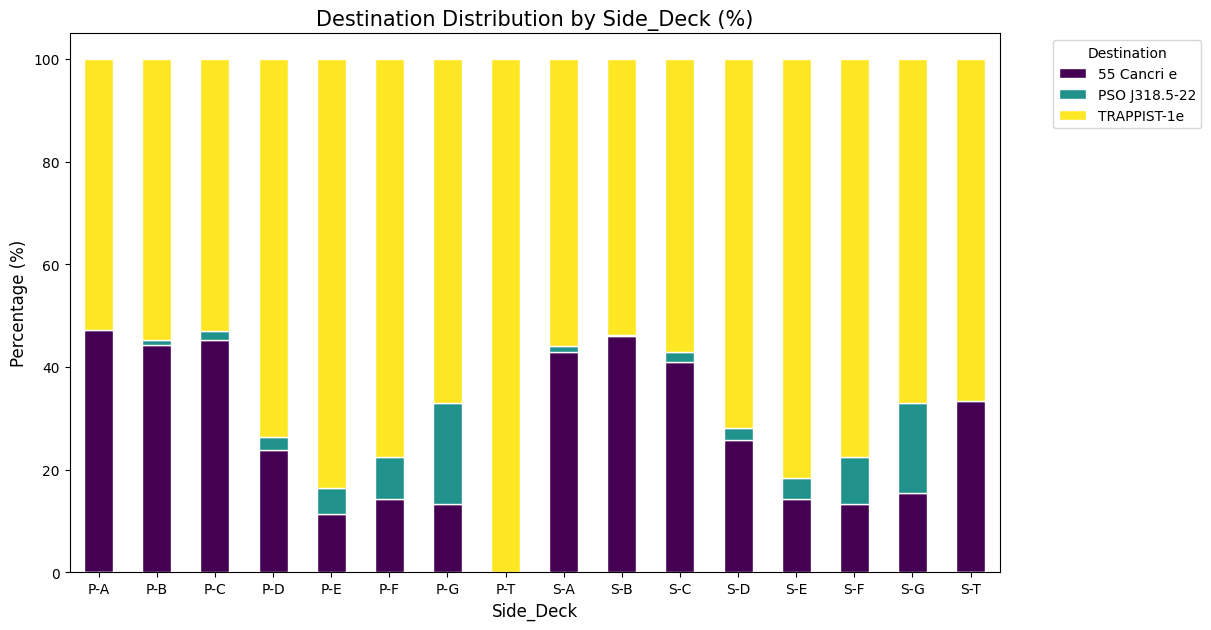

In [56]:
# 1. Deck과 Destination 간의 교차표 생성 (승객 수 기준)
deck_dest_table = pd.crosstab(df_norm['Side_Deck'], df_norm['Destination'])

# 2. 비율로 변환 (각 덱 내에서 목적지 비중 확인)
deck_dest_pct = pd.crosstab(df_norm['Side_Deck'], df_norm['Destination'], normalize='index') * 100

print("=== [1] Side_Deck별 Destination 승객 수 ===")
display(deck_dest_table)

print("\n=== [2] Side_Deck별 Destination 점유 비율 (%) ===")
display(deck_dest_pct.style.format("{:.2f}%").background_gradient(cmap='YlOrRd', axis=1))

# 3. 시각화 (Stacked Bar Chart)
import matplotlib.pyplot as plt

deck_dest_pct.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis', edgecolor='white')
plt.title('Destination Distribution by Side_Deck (%)', fontsize=15)
plt.xlabel('Side_Deck', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Destination', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

#### 덱별로 목적지가 비슷하다... True와 False 대신 1과 0, 결측치는 확률로 넣어볼까?

In [58]:
# 1. One-hot encoded Destination columns을 float 타입으로 변환하여 확률 값을 저장할 수 있도록 합니다.
dest_ohe_cols = ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e']
for col in dest_ohe_cols:
    df_norm[col] = df_norm[col].astype(float)

# 2. 'Destination' 컬럼에 결측치가 있는 행의 인덱스를 식별합니다.
nan_destination_indices = df_norm[df_norm['Destination'].isnull()].index

# 3. Side_Deck 정보가 없는 경우를 대비하여 전체 목적지 비율을 가져옵니다.
global_dest_ratios = dest_ratio.copy() # dest_ratio는 이미 0~1 사이의 값으로 가정

# 4. 결측치 행을 순회하며 확률로 채웁니다.
for idx in nan_destination_indices:
    side_deck_value = df_norm.loc[idx, 'Side_Deck']

    probabilities_to_assign = None
    # Side_Deck 정보가 유효하고 deck_dest_pct에 해당 정보가 있는 경우
    if pd.notna(side_deck_value) and side_deck_value in deck_dest_pct.index:
        # deck_dest_pct는 퍼센트 값이므로 100으로 나눔
        probabilities_to_assign = deck_dest_pct.loc[side_deck_value, :] / 100
    else:
        # Side_Deck 정보가 없거나 유효하지 않으면 전체 목적지 비율을 사용합니다.
        probabilities_to_assign = global_dest_ratios

    # 해당 행의 one-hot encoded destination 컬럼에 확률 값을 할당합니다.
    if probabilities_to_assign is not None:
        for dest_col_name in dest_ohe_cols:
            df_norm.loc[idx, dest_col_name] = probabilities_to_assign.get(dest_col_name, 0.0)

# 5. 처리 결과를 확인하기 위해, 원래 Destination이 NaN이었던 행들의 일부를 출력합니다.
print("\n--- Destination 결측치 처리 후 df_norm의 일부 행 확인 (원래 Destination이 NaN이었던 행): ---")
display(df_norm.loc[nan_destination_indices].head())

# 6. 변경된 DataFrame의 정보(Dtype 등)를 확인합니다.
print("\n--- DataFrame info after processing Destination probabilities: ---")
df_norm.info()



--- Destination 결측치 처리 후 df_norm의 일부 행 확인 (원래 Destination이 NaN이었던 행): ---


,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,P,S,A,B,C,D,E,F,G,T
47,0045,02,Mars,True,F,10,P,NaN,0.240506,False,...,True,False,False,False,False,False,False,True,False,False
128,0138,02,Earth,False,E,5,P,NaN,0.430380,False,...,True,False,False,False,False,False,True,False,False,False
139,0152,01,Earth,False,F,32,P,NaN,0.518987,False,...,True,False,False,False,False,False,False,True,False,False
347,0382,01,None,False,G,64,P,NaN,0.291139,False,...,True,False,False,False,False,False,False,False,True,False
430,0462,01,Earth,True,G,67,S,NaN,0.632911,False,...,False,True,False,False,False,False,False,False,True,False



--- DataFrame info after processing Destination probabilities: ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Group          12970 non-null  object 
 1   BoardingOrder  12970 non-null  object 
 2   HomePlanet     12813 non-null  object 
 3   CryoSleep      12660 non-null  object 
 4   Deck           12671 non-null  object 
 5   CabinNum       12671 non-null  object 
 6   CabinSide      12808 non-null  object 
 7   Destination    12696 non-null  object 
 8   Age            12970 non-null  float64
 9   VIP            12970 non-null  bool   
 10  RoomService    12970 non-null  float64
 11  FoodCourt      12970 non-null  float64
 12  ShoppingMall   12970 non-null  float64
 13  Spa            12970 non-null  float64
 14  VRDeck         12970 non-null  float64
 15  Name           12676 non-null  object 
 16  Side_Deck      12671 non-n

### 6-2. 나이정보로 결측지 채워넣기

#### 이번엔 나이 x 덱별로 평균 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck' 지출을 결측체에 체워넣기

In [61]:
## 이미 정규화를 시키고나니 값이 이상해서... 원래 데이터 다시 불러오기 ㅠㅠ
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
restore_cols = ['Age'] + exp_cols

# Restore original values from the 'data' DataFrame
df_norm[restore_cols] = data[restore_cols]

print("=== 'Age' and expenditure columns restored to original values in df_norm ===")
print(df_norm[restore_cols].isnull().sum())
df_norm[restore_cols].head()

=== 'Age' and expenditure columns restored to original values in df_norm ===
Age             270
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
dtype: int64


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,39.0,0.0,0.0,0.0,0.0,0.0
1,24.0,109.0,9.0,25.0,549.0,44.0
2,58.0,43.0,3576.0,0.0,6715.0,49.0
3,33.0,0.0,1283.0,371.0,3329.0,193.0
4,16.0,303.0,70.0,151.0,565.0,2.0


#### Side-Deck별 평균나이를 계산해서 해당 side-Deck에 Age 가 결측치인 데 넣기

In [66]:
side_deck_avg_age = df_norm.groupby('Side_Deck')['Age'].mean()

print("=== Mean Age by Side_Deck ===")
display(side_deck_avg_age.head())


=== Mean Age by Side_Deck ===


,Age
Side_Deck,
P-A,35.725000
P-B,33.152778
P-C,34.019268
P-D,32.847645
P-E,30.145136


In [68]:
df_norm['Age'] = df_norm.groupby('Side_Deck')['Age'].transform(lambda x: x.fillna(x.mean()))

overall_mean_age = df_norm['Age'].mean()
df_norm['Age'] = df_norm['Age'].fillna(overall_mean_age)

print("=== Missing Age values after imputation ===")
print(df_norm['Age'].isnull().sum())

=== Missing Age values after imputation ===
0


### 6-3. 놓친 결측치 안채워 넣은거 다시 한번 확인

#### Side_Deck Earth : Europa : Mars True 계수를 비율로 계산하고 각 출항지가 True면 1, False면 0, 결측치면 해당 Sdie_Deck이 어딘지 확인하여 Earth : Europa : Mars 각 값에 비율을 넣기

In [71]:
homeplanet_ohe_cols = ['Earth', 'Europa', 'Mars']

for col in homeplanet_ohe_cols:
    df_norm[col] = df_norm[col].astype(float)

print("=== Data types of HomePlanet OHE columns after conversion: ===")
print(df_norm[homeplanet_ohe_cols].dtypes)

=== Data types of HomePlanet OHE columns after conversion: ===
Earth     float64
Europa    float64
Mars      float64
dtype: object


이거 이후론 시간이 모자라 제미나이 코드 생성에 많이 의지 했음..!

In [72]:
homeplanet_list = ['Earth', 'Europa', 'Mars']

# 1. Calculate global HomePlanet ratios
global_homeplanet_ratios = df_norm['HomePlanet'].value_counts(normalize=True)

# 2. Calculate HomePlanet ratios by Side_Deck
# Create a cross-tabulation table for Side_Deck and HomePlanet
side_deck_homeplanet_table = pd.crosstab(df_norm['Side_Deck'], df_norm['HomePlanet'])

# Convert counts to percentages within each Side_Deck
side_deck_homeplanet_pct = pd.crosstab(df_norm['Side_Deck'], df_norm['HomePlanet'], normalize='index')

print("=== Global HomePlanet Ratios ===")
print(global_homeplanet_ratios)
print("\n=== Side_Deck HomePlanet Ratios (first 5 rows) ===")
print(side_deck_homeplanet_pct.head())

=== Global HomePlanet Ratios ===
HomePlanet
Earth     0.539608
Europa    0.247795
Mars      0.212597
Name: proportion, dtype: float64

=== Side_Deck HomePlanet Ratios (first 5 rows) ===
HomePlanet     Earth    Europa      Mars
Side_Deck                               
P-A         0.000000  1.000000  0.000000
P-B         0.000000  1.000000  0.000000
P-C         0.000000  1.000000  0.000000
P-D         0.000000  0.426997  0.573003
P-E         0.457278  0.156646  0.386076


In [73]:
homeplanet_ohe_cols = ['Earth', 'Europa', 'Mars']

# Identify rows where 'HomePlanet' is NaN
nan_homeplanet_indices = df_norm[df_norm['HomePlanet'].isnull()].index

# Iterate through each identified index
for idx in nan_homeplanet_indices:
    side_deck_value = df_norm.loc[idx, 'Side_Deck']

    probabilities_to_assign = None
    # Check if Side_Deck is valid and available in the calculated percentages
    if pd.notna(side_deck_value) and side_deck_value in side_deck_homeplanet_pct.index:
        probabilities_to_assign = side_deck_homeplanet_pct.loc[side_deck_value, :]
    else:
        # Fallback to global ratios if Side_Deck is missing or not found
        probabilities_to_assign = global_homeplanet_ratios

    # Assign the probabilities to the one-hot encoded columns
    if probabilities_to_assign is not None:
        for hp_col_name in homeplanet_ohe_cols:
            df_norm.loc[idx, hp_col_name] = probabilities_to_assign.get(hp_col_name, 0.0)

# Verify imputation by checking null counts in the OHE columns
print("\n--- Null counts in HomePlanet OHE columns after imputation: ---")
print(df_norm[homeplanet_ohe_cols].isnull().sum())

# Display some of the imputed rows for verification
print("\n--- Sample of imputed HomePlanet OHE rows (originally NaN): ---")
display(df_norm.loc[nan_homeplanet_indices].head())


--- Null counts in HomePlanet OHE columns after imputation: ---
Earth     0
Europa    0
Mars      0
dtype: int64

--- Sample of imputed HomePlanet OHE rows (originally NaN): ---


,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,S,A,B,C,D,E,F,G,T,Age_Bin
186,0210,01,None,True,D,6,P,55 Cancri e,24.0,False,...,False,False,False,False,True,False,False,False,False,20-24
225,0242,01,None,False,F,46,S,TRAPPIST-1e,18.0,False,...,True,False,False,False,False,False,True,False,False,15-19
234,0251,01,None,True,C,11,S,55 Cancri e,54.0,False,...,True,False,False,True,False,False,False,False,False,50-54
274,0303,01,None,True,G,41,S,TRAPPIST-1e,23.0,False,...,True,False,False,False,False,False,False,True,False,20-24
286,0315,01,None,True,G,42,S,PSO J318.5-22,35.0,False,...,True,False,False,False,False,False,False,True,False,35-39


In [74]:
print("=== CryoSleep unique values and their counts ===")
print(df_norm['CryoSleep'].value_counts(dropna=False))

print("\n=== CryoSleep unique values and their ratios ===")
print(df_norm['CryoSleep'].value_counts(normalize=True, dropna=False).map(lambda x: f"{x:.2%}"))

=== CryoSleep unique values and their counts ===
CryoSleep
False    8079
True     4581
NaN       310
Name: count, dtype: int64

=== CryoSleep unique values and their ratios ===
CryoSleep
False    62.29%
True     35.32%
NaN       2.39%
Name: proportion, dtype: object


In [75]:
nan_cryosleep_indices = df_norm[df_norm['CryoSleep'].isnull()].index

# For rows where CryoSleep is NaN and TotalExp is 0, set CryoSleep to True
df_norm.loc[(df_norm['CryoSleep'].isnull()) & (df_norm['TotalExp'] == 0), 'CryoSleep'] = True

# For rows where CryoSleep is NaN and TotalExp > 0, set CryoSleep to False
df_norm.loc[(df_norm['CryoSleep'].isnull()) & (df_norm['TotalExp'] > 0), 'CryoSleep'] = False

# Convert CryoSleep to boolean type after imputation
df_norm['CryoSleep'] = df_norm['CryoSleep'].astype(bool)

print("=== CryoSleep imputation based on TotalExp completed. ===")
print("Remaining NaN values in CryoSleep:", df_norm['CryoSleep'].isnull().sum())
print("CryoSleep data type:", df_norm['CryoSleep'].dtype)
display(df_norm.loc[nan_cryosleep_indices].head())

=== CryoSleep imputation based on TotalExp completed. ===
Remaining NaN values in CryoSleep: 0
CryoSleep data type: bool


,Group,BoardingOrder,HomePlanet,CryoSleep,Deck,CabinNum,CabinSide,Destination,Age,VIP,...,S,A,B,C,D,E,F,G,T,Age_Bin
92,0099,02,Earth,True,G,12,P,TRAPPIST-1e,2.0,False,...,False,False,False,False,False,False,False,True,False,0-4
98,0105,01,Earth,False,F,21,P,TRAPPIST-1e,27.0,False,...,False,False,False,False,False,False,True,False,False,25-29
104,0110,02,Europa,False,B,5,P,TRAPPIST-1e,40.0,False,...,False,False,True,False,False,False,False,False,False,40-44
111,0115,01,Mars,True,F,24,P,TRAPPIST-1e,26.0,False,...,False,False,False,False,False,False,True,False,False,25-29
152,0173,01,Earth,False,E,11,S,TRAPPIST-1e,58.0,False,...,True,False,False,False,False,True,False,False,False,55-59


In [76]:
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in exp_cols:
    df_norm.loc[(df_norm['CryoSleep'] == True) & (df_norm[col].isnull()), col] = 0

print("=== Expenditure columns imputed to 0 where CryoSleep is True and value is NaN. ===")
print(df_norm[exp_cols].isnull().sum())


=== Expenditure columns imputed to 0 where CryoSleep is True and value is NaN. ===
RoomService     170
FoodCourt       179
ShoppingMall    172
Spa             173
VRDeck          172
dtype: int64


In [77]:
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in exp_cols:
    median_val = df_norm.loc[df_norm['CryoSleep'] == False, col].median()
    df_norm.loc[(df_norm['CryoSleep'] == False) & (df_norm[col].isnull()), col] = median_val

print("=== Expenditure columns imputed with median for non-CryoSleep passengers. ===")
print(df_norm[exp_cols].isnull().sum())


=== Expenditure columns imputed with median for non-CryoSleep passengers. ===
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64


In [80]:
cols_to_drop = ['HomePlanet', 'Destination', 'Name']

df_norm = df_norm.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print("Current DataFrame info after dropping columns:")
df_norm.info()

Dropped columns: ['HomePlanet', 'Destination', 'Name']
Current DataFrame info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 33 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Group          12970 non-null  object  
 1   BoardingOrder  12970 non-null  object  
 2   CryoSleep      12970 non-null  bool    
 3   Deck           12671 non-null  object  
 4   CabinNum       12671 non-null  object  
 5   CabinSide      12808 non-null  object  
 6   Age            12970 non-null  float64 
 7   VIP            12970 non-null  bool    
 8   RoomService    12970 non-null  float64 
 9   FoodCourt      12970 non-null  float64 
 10  ShoppingMall   12970 non-null  float64 
 11  Spa            12970 non-null  float64 
 12  VRDeck         12970 non-null  float64 
 13  Side_Deck      12671 non-null  object  
 14  TotalExp       12970 non-null  float64 
 15  Deck_Num       1267

In [81]:
cabin_side_ohe_cols = ['P', 'S']

for col in cabin_side_ohe_cols:
    df_norm[col] = df_norm[col].astype(float)

print("=== Data types of CabinSide OHE columns after conversion: ===")
print(df_norm[cabin_side_ohe_cols].dtypes)

=== Data types of CabinSide OHE columns after conversion: ===
P    float64
S    float64
dtype: object


In [82]:
cabin_side_ohe_cols = ['P', 'S']

# 1. Calculate global CabinSide ratios
global_cabinside_ratios = df_norm['CabinSide'].value_counts(normalize=True)

# 2. Calculate CabinSide ratios by Side_Deck
# Create a cross-tabulation table for Side_Deck and CabinSide
side_deck_cabinside_table = pd.crosstab(df_norm['Side_Deck'], df_norm['CabinSide'])

# Convert counts to percentages within each Side_Deck
side_deck_cabinside_pct = pd.crosstab(df_norm['Side_Deck'], df_norm['CabinSide'], normalize='index')

print("=== Global CabinSide Ratios ===")
print(global_cabinside_ratios)
print("\n=== Side_Deck CabinSide Ratios (first 5 rows) ===")
print(side_deck_cabinside_pct.head())

=== Global CabinSide Ratios ===
CabinSide
S    0.503904
P    0.496096
Name: proportion, dtype: float64

=== Side_Deck CabinSide Ratios (first 5 rows) ===
CabinSide    P    S
Side_Deck          
P-A        1.0  0.0
P-B        1.0  0.0
P-C        1.0  0.0
P-D        1.0  0.0
P-E        1.0  0.0


In [83]:
cabin_side_ohe_cols = ['P', 'S']

# Identify rows where 'CabinSide' is NaN
nan_cabinside_indices = df_norm[df_norm['CabinSide'].isnull()].index

# Iterate through each identified index
for idx in nan_cabinside_indices:
    side_deck_value = df_norm.loc[idx, 'Side_Deck']

    probabilities_to_assign = None
    # Check if Side_Deck is valid and available in the calculated percentages
    if pd.notna(side_deck_value) and side_deck_value in side_deck_cabinside_pct.index:
        probabilities_to_assign = side_deck_cabinside_pct.loc[side_deck_value, :]
    else:
        # Fallback to global ratios if Side_Deck is missing or not found
        probabilities_to_assign = global_cabinside_ratios

    # Assign the probabilities to the one-hot encoded columns 'P' and 'S'
    if probabilities_to_assign is not None:
        for cs_col_name in cabin_side_ohe_cols:
            # Ensure probabilities_to_assign.get(cs_col_name, 0.0) covers both Series and DataFrame cases
            if isinstance(probabilities_to_assign, pd.Series):
                df_norm.loc[idx, cs_col_name] = probabilities_to_assign.get(cs_col_name, 0.0)
            elif isinstance(probabilities_to_assign, pd.DataFrame):
                df_norm.loc[idx, cs_col_name] = probabilities_to_assign.iloc[0].get(cs_col_name, 0.0)

# Verify imputation by checking null counts in the OHE columns
print("\n--- Null counts in CabinSide OHE columns after imputation: ---")
print(df_norm[cabin_side_ohe_cols].isnull().sum())

# Display some of the imputed rows for verification
print("\n--- Sample of imputed CabinSide OHE rows (originally NaN): ---")
display(df_norm.loc[nan_cabinside_indices].head())


--- Null counts in CabinSide OHE columns after imputation: ---
P    0
S    0
dtype: int64

--- Sample of imputed CabinSide OHE rows (originally NaN): ---


,Group,BoardingOrder,CryoSleep,Deck,CabinNum,CabinSide,Age,VIP,RoomService,FoodCourt,...,S,A,B,C,D,E,F,G,T,Age_Bin
15,0012,01,False,NaN,NaN,None,28.766876,False,32.0,0.0,...,0.503904,False,False,False,False,False,False,False,False,30-34
93,0101,01,True,NaN,NaN,None,28.766876,False,0.0,0.0,...,0.503904,False,False,False,False,False,False,False,False,30-34
222,0239,01,False,NaN,NaN,None,28.766876,False,637.0,0.0,...,0.503904,False,False,False,False,False,False,False,False,35-39
272,0301,01,True,NaN,NaN,None,28.766876,False,0.0,0.0,...,0.503904,False,False,False,False,False,False,False,False,15-19
280,0310,01,False,NaN,NaN,None,28.766876,False,3.0,230.0,...,0.503904,False,False,False,False,False,False,False,False,65-69


In [84]:
cols_to_drop_cabin = ['CabinSide', 'Deck', 'CabinNum', 'Side_Deck']

df_norm = df_norm.drop(columns=cols_to_drop_cabin)

print(f"Dropped columns: {cols_to_drop_cabin}")
print("Current DataFrame info after dropping cabin-related columns:")
df_norm.info()

Dropped columns: ['CabinSide', 'Deck', 'CabinNum', 'Side_Deck']
Current DataFrame info after dropping cabin-related columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Group          12970 non-null  object  
 1   BoardingOrder  12970 non-null  object  
 2   CryoSleep      12970 non-null  bool    
 3   Age            12970 non-null  float64 
 4   VIP            12970 non-null  bool    
 5   RoomService    12970 non-null  float64 
 6   FoodCourt      12970 non-null  float64 
 7   ShoppingMall   12970 non-null  float64 
 8   Spa            12970 non-null  float64 
 9   VRDeck         12970 non-null  float64 
 10  TotalExp       12970 non-null  float64 
 11  Deck_Num       12671 non-null  float64 
 12  Earth          12970 non-null  float64 
 13  Europa         12970 non-null  float64 
 14  Mars           12970 non-null  float64 
 

In [85]:
homeplanet_ohe_cols = ['Earth', 'Europa', 'Mars']

for col in homeplanet_ohe_cols:
    df_norm[col] = df_norm[col].astype(float)

print("=== Data types of HomePlanet OHE columns after conversion: ===")
print(df_norm[homeplanet_ohe_cols].dtypes)

=== Data types of HomePlanet OHE columns after conversion: ===
Earth     float64
Europa    float64
Mars      float64
dtype: object


In [86]:
deck_num_mode = df_norm['Deck_Num'].mode()[0]
df_norm['Deck_Num'] = df_norm['Deck_Num'].fillna(deck_num_mode)

print(f"Missing values in 'Deck_Num' after imputation: {df_norm['Deck_Num'].isnull().sum()}")
print(df_norm['Deck_Num'].value_counts(dropna=False).sort_index())

Missing values in 'Deck_Num' after imputation: 0
Deck_Num
1.0     354
2.0    1141
3.0    1102
4.0     720
5.0    1323
6.0    4538
7.0    3781
8.0      11
Name: count, dtype: int64


In [88]:
if 'Age_Bin' not in df_norm.columns:
    # Assuming 'Age' column exists and is already imputed
    bins = [0, 12, 17, 25, 35, 60, df_norm['Age'].max()]
    labels = ['0-12', '13-17', '18-25', '26-35', '36-60', '60+']
    df_norm['Age_Bin'] = pd.cut(df_norm['Age'], bins=bins, labels=labels, right=False)

# Calculate the mode of the 'Age_Bin' column
age_bin_mode = df_norm['Age_Bin'].mode()[0]

# Fill missing values (NaNs) in 'Age_Bin' with the calculated mode
df_norm['Age_Bin'] = df_norm['Age_Bin'].fillna(age_bin_mode)

# Verify that there are no remaining missing values in the 'Age_Bin' column
print(f"Missing values in 'Age_Bin' after imputation: {df_norm['Age_Bin'].isnull().sum()}")
print("Value counts of 'Age_Bin' after imputation:")
print(df_norm['Age_Bin'].value_counts(dropna=False).sort_index())

Missing values in 'Age_Bin' after imputation: 0
Value counts of 'Age_Bin' after imputation:
Age_Bin
0-4       664
5-9       316
10-14     595
15-19    1640
20-24    2547
25-29    1913
30-34    1334
35-39    1204
40-44     928
45-49     642
50-54     457
55-59     352
60-64     217
65-69      95
70-74      46
75-79      20
Name: count, dtype: int64


Group : 0
BoardingOrder : 0
CryoSleep : 0
Age : 0
VIP : 0
RoomService : 0
FoodCourt : 0
ShoppingMall : 0
Spa : 0
VRDeck : 0
TotalExp : 0
Deck_Num : 0
Earth : 0
Europa : 0
Mars : 0
55 Cancri e : 0
PSO J318.5-22 : 0
TRAPPIST-1e : 0
P : 0
S : 0
A : 0
B : 0
C : 0
D : 0
E : 0
F : 0
G : 0
T : 0
Age_Bin : 0


<Axes: >

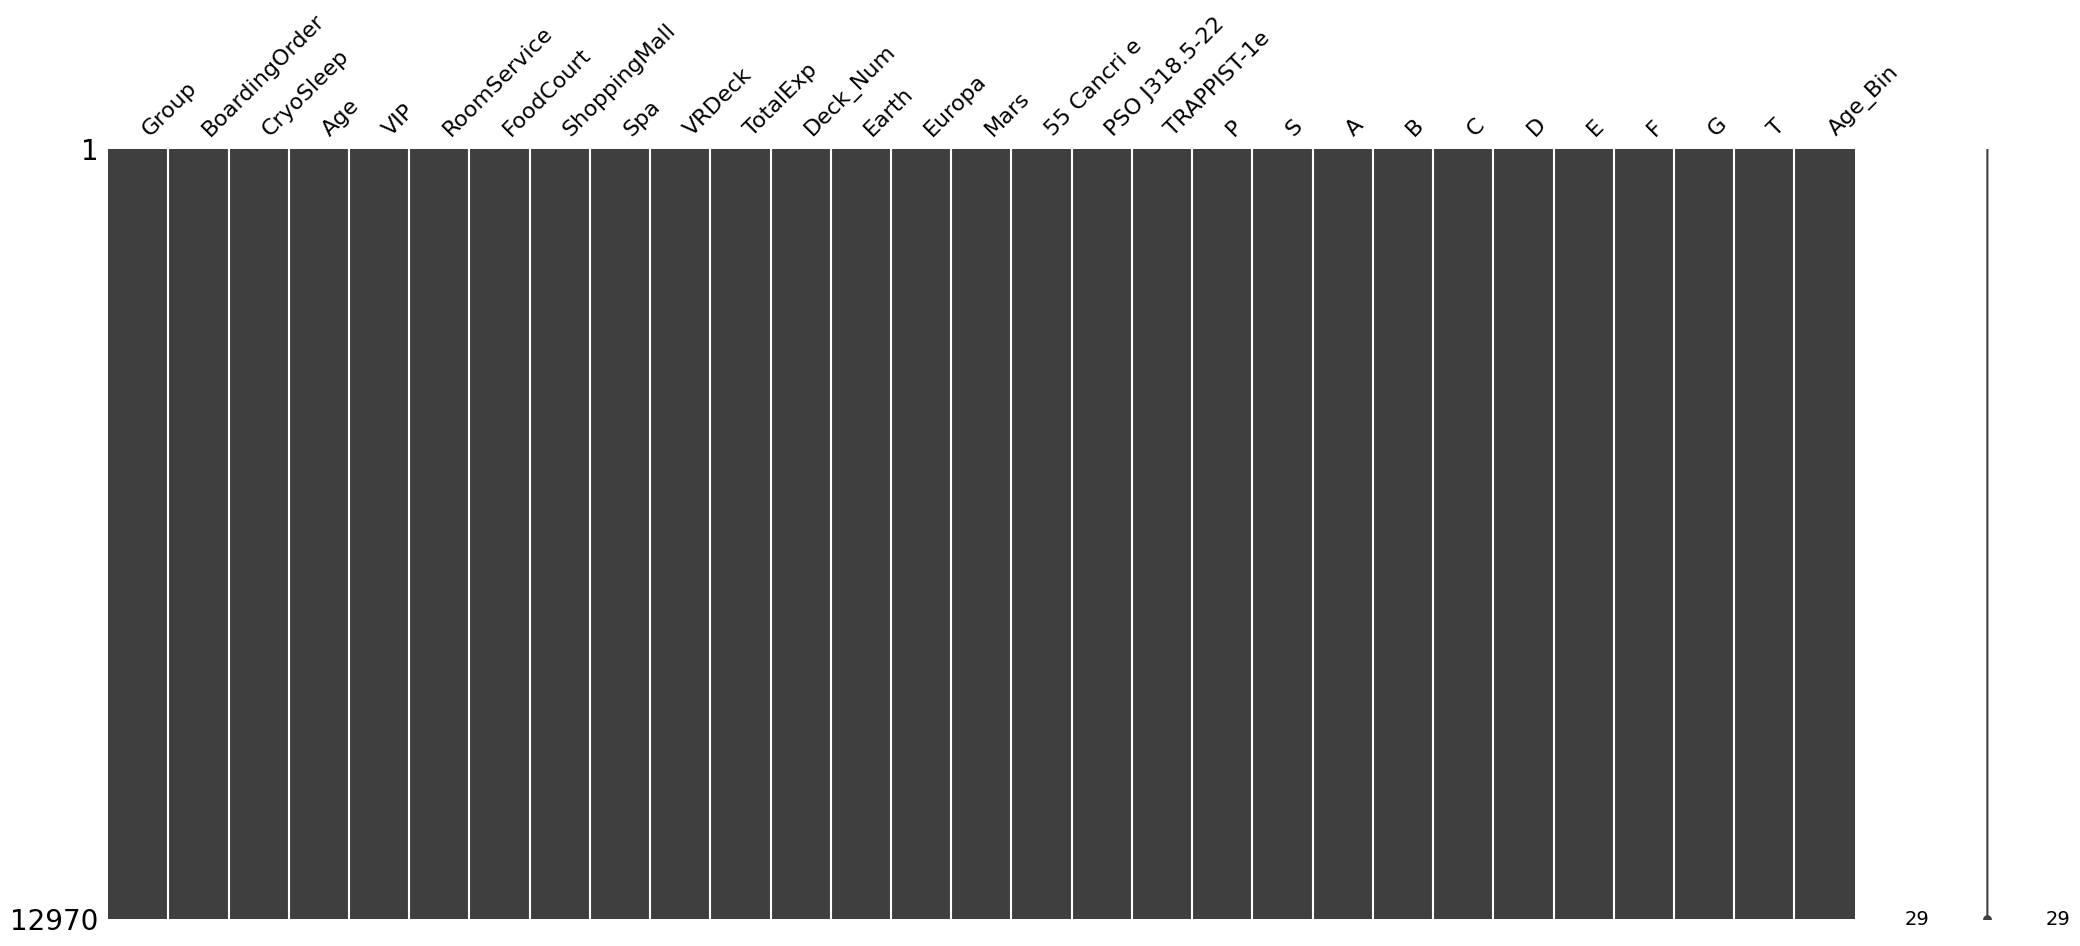

In [90]:
for c in df_norm.columns:
    print('{} : {}'.format(c, len(df_norm.loc[pd.isnull(df_norm[c]), c].values)))

msno.matrix(df_norm)

In [91]:
df_norm.head()

,Group,BoardingOrder,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,...,S,A,B,C,D,E,F,G,T,Age_Bin
0,0001,01,False,39.0,False,0.0,0.0,0.0,0.0,0.0,...,0.0,False,True,False,False,False,False,False,False,35-39
1,0002,01,False,24.0,False,109.0,9.0,25.0,549.0,44.0,...,1.0,False,False,False,False,False,True,False,False,20-24
2,0003,01,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,...,1.0,True,False,False,False,False,False,False,False,55-59
3,0003,02,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,...,1.0,True,False,False,False,False,False,False,False,30-34
4,0004,01,False,16.0,False,303.0,70.0,151.0,565.0,2.0,...,1.0,False,False,False,False,False,True,False,False,15-19


In [93]:
fn_norm = df_norm


In [94]:
from sklearn.preprocessing import MinMaxScaler

# Define columns to normalize
columns_to_normalize = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max scaling to the selected columns in fn_norm
fn_norm[columns_to_normalize] = scaler.fit_transform(fn_norm[columns_to_normalize])

print("=== Age and Expenditure columns normalized to 0-1 range in fn_norm ===")
display(fn_norm[columns_to_normalize].describe())

=== Age and Expenditure columns normalized to 0-1 range in fn_norm ===


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,12970.000000,12970.000000,12970.000000,12970.000000,12970.000000,12970.000000
mean,0.364138,0.015245,0.014825,0.007271,0.013470,0.012452
std,0.178230,0.044793,0.052595,0.024866,0.049925,0.048425
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.253165,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.341772,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.468354,0.002984,0.002105,0.000979,0.002231,0.001492
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [95]:
fn_norm.head()

,Group,BoardingOrder,CryoSleep,Age,VIP,...,E,F,G,T,Age_Bin
0,0001,01,False,0.493671,False,...,False,False,False,False,35-39
1,0002,01,False,0.303797,False,...,False,True,False,False,20-24
2,0003,01,False,0.734177,True,...,False,False,False,False,55-59
3,0003,02,False,0.417722,False,...,False,False,False,False,30-34
4,0004,01,False,0.202532,False,...,False,True,False,False,15-19


## 7. 상관계수 분석하기

### 7-1. 정규화한 데이터를 트레인 데이터와 테스트 데이터 분리

In [98]:
y.head()
fn_train = fn_norm[:len(y)]
fn_test = fn_norm[len(y):]
fn_train.info()
fn_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Group          8693 non-null   object  
 1   BoardingOrder  8693 non-null   object  
 2   CryoSleep      8693 non-null   bool    
 3   Age            8693 non-null   float64 
 4   VIP            8693 non-null   bool    
 5   RoomService    8693 non-null   float64 
 6   FoodCourt      8693 non-null   float64 
 7   ShoppingMall   8693 non-null   float64 
 8   Spa            8693 non-null   float64 
 9   VRDeck         8693 non-null   float64 
 10  TotalExp       8693 non-null   float64 
 11  Deck_Num       8693 non-null   float64 
 12  Earth          8693 non-null   float64 
 13  Europa         8693 non-null   float64 
 14  Mars           8693 non-null   float64 
 15  55 Cancri e    8693 non-null   float64 
 16  PSO J318.5-22  8693 non-null   float64 
 17  TRAPPIST-1e    8693 non-null   fl

### 7-2. 결과치랑 각 컬럼간의 상관관계 분석

하고자 했으나 참고하려는 LMS도 제미나이도 다 먹통이 되었고 + 시간이 얼마 남지 않아.... 그냥 다음 단계로

## 8. 학습 시작

### 8-1. 모델링

In [103]:
train_columns = [
    'CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalExp', 'Earth', 'Europa', 'Mars', '55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e', 'P', 'S', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'
]
X_train = fn_train[train_columns]
X_train.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalExp,Earth,...,P,S,A,B,C,D,E,F,G,T
0,False,0.493671,False,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,1.0,0.0,False,True,False,False,False,False,False,False
1,False,0.303797,False,0.007608,0.000302,0.001064,0.024500,0.001823,736.0,1.0,...,0.0,1.0,False,False,False,False,False,True,False,False
2,False,0.734177,True,0.003001,0.119948,0.000000,0.299670,0.002030,10383.0,0.0,...,0.0,1.0,True,False,False,False,False,False,False,False
3,False,0.417722,False,0.000000,0.043035,0.015793,0.148563,0.007997,5176.0,0.0,...,0.0,1.0,True,False,False,False,False,False,False,False
4,False,0.202532,False,0.021149,0.002348,0.006428,0.025214,0.000083,1091.0,1.0,...,0.0,1.0,False,False,False,False,False,True,False,False


### 7-2. 결과치(`y`)와 각 컬럼(`X_train`)간의 상관관계 분석

=== 'Transported'와의 상관계수 (내림차순) ===


,Transported
Transported,1.000000
CryoSleep,0.467230
Europa,0.180432
B,0.144733
55 Cancri e,0.110034
C,0.108193
S,0.103122
FoodCourt,0.045566
Mars,0.019755
G,0.016269


/tmp/ipython-input-835646549.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.index, y=correlations.values, palette='viridis')


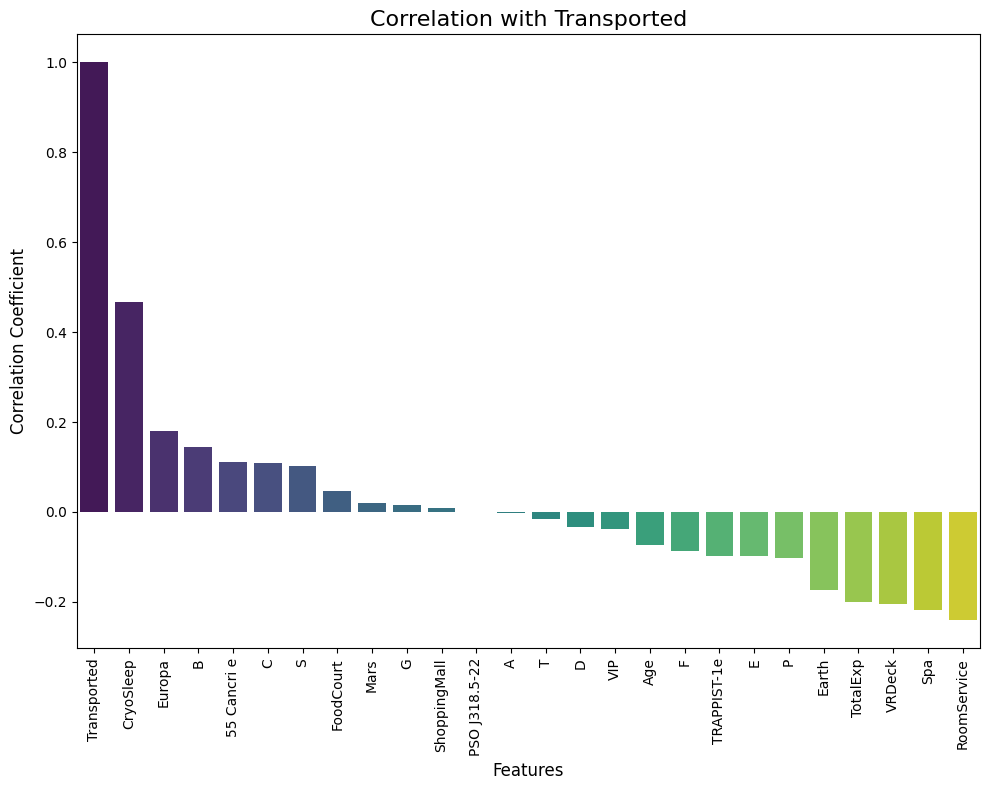

In [111]:
# y와 X_train을 합쳐서 상관계수를 계산할 DataFrame 생성
correlation_data = X_train.copy()
correlation_data['Transported'] = y

# 상관계수 계산
correlations = correlation_data.corr()['Transported'].sort_values(ascending=False)

print("=== 'Transported'와의 상관계수 (내림차순) ===")
display(correlations)

# 상관계수 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.index, y=correlations.values, palette='viridis')
plt.title('Correlation with Transported', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline

# 파이프라인 생성 (스케일링 + 모델 학습을 한 번에)
model = make_pipeline(StandardScaler(), RandomForestClassifier())

#학습
model.fit(X_train, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('randomforestclassifier', RandomForestClassifier())])

### 8-2. 테스트

In [105]:

X_test = fn_test[train_columns]
X_test.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalExp,Earth,...,P,S,A,B,C,D,E,F,G,T
8693,True,0.341772,False,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,1.0,...,0.0,1.0,False,False,False,False,False,False,True,False
8694,False,0.240506,False,0.000000,0.000302,0.00000,0.125982,0.000000,2832.0,1.0,...,0.0,1.0,False,False,False,False,False,True,False,False
8695,True,0.392405,False,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,...,0.0,1.0,False,False,True,False,False,False,False,False
8696,False,0.481013,False,0.000000,0.223124,0.00000,0.008077,0.024241,7418.0,0.0,...,0.0,1.0,False,False,True,False,False,False,False,False
8697,False,0.253165,False,0.000698,0.000000,0.02703,0.000000,0.000000,645.0,1.0,...,0.0,1.0,False,False,False,False,False,True,False,False


In [106]:
# 1. X_test 데이터를 사용하여 결과 예측
# 결과는 [True, False, True, ...] 형태의 numpy array로 반환됩니다.
predictions = model.predict(X_test)

# 2. 예측된 결과(Transported 값)를 리스트로 변환
transported_list = predictions.tolist()

# 결과 확인 (상위 10개만 출력)
print(transported_list[:10])

[True, False, True, True, False, True, True, True, True, True]


### 8-3. 결과를 형식에 맞게 저장

In [109]:


# 1. 모델을 사용하여 X_test 데이터 예측
# 결과가 0, 1로 나올 경우를 대비해 .astype(bool)을 추가하면 안전합니다.
predictions = model.predict(X_test).astype(bool)

# 2. 원본 test 데이터의 PassengerId와 예측 결과를 합쳐 데이터프레임 생성
# (test_df는 전처리 전 원본 데이터를 불러온 변수명을 사용하세요)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': predictions
})

# 3. CSV 파일로 저장 (Index는 제외해야 제출 형식에 맞습니다)
submission.to_csv('/content/gdrive/MyDrive/#Study/Aiffel/Work/Kaggle/spaceship_titanic/submission.csv', index=False)

print("제출 파일 'submission.csv'가 성공적으로 생성되었습니다!")

제출 파일 'submission.csv'가 성공적으로 생성되었습니다!


### 8-4. 채점 결과

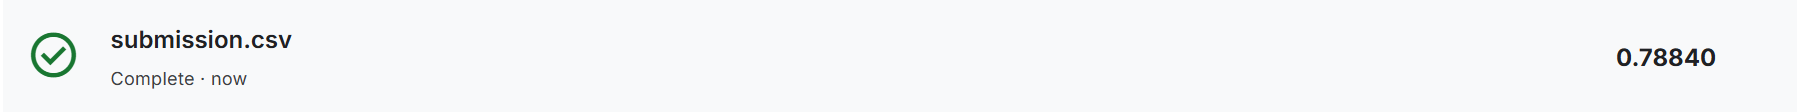

## 9. 회고

지난 주 LMS 접속 불량으로 시간 잡아 먹은게 생각나,  
녹북에 학습환경을 마련하고자 했으나   
주피터 노트북 설치하는데에서 막혀 더이상 진행하지 못했다.
(심지어 원래 쓰던 노트북 갑자기 고장나는 바람에
급하게 예전에 쓰던 노트북 어제 밤새 초기화 하고 아침에야 겨우 쓸 수 있는 상태로 만들어 놓은 거라 파이썬도, 아나콘다도 VScode도 아무것도 없는 상태였던...)

LMS 로는 지난주와 비슷한 사태가 날꺼 같고
코랩을 안정적으로 사용하기 위해서 유료결제까지 했으나
후반에 가니 중간에 런타임 연결이 이놈도 자주 끊겨서 데이터 분석을 마무리 못한 상태에서 학습에 들어가게 되었다.

결국 컬럼과 결과치에 관련된 상관계수도 따져보지 못했고,
모델도 그냥 제미나이가 추천해준걸로 간략히 돌려보았고...
결론 점수가 너무 낮다...!

데이터 전처리 하는 순서나, 이런 부분에서
전사적으로 계획을 잡고 들어갔어야 하는데,
시작이 1시간 반 이상 늦어져 조급함에 눈에 보이고 생각난거 부터 진행했던게 폐착의 원인인거 같다.

학습 컬럼을 몇개 바꾸어보며 다시 학습시킬까 하다,
이보다는 전체 내가 작성한 코드 회고해보고, 방향을 잡는 것이 더 나을 듯 하여
전체적으로 돌아보는 시간을 먼저 갖어 보았다.

확실히 여러예제를 반복해서 연습해보는 경험이 중요한 것 같단 생각이 들었다.

잃단 이번에는 제시간 안에 끝낸 것에 의의를 두고
밀린 예제들 학습 다시 해 본 뒤에
처음부터 차근 차근 계획을 세워 다시 도전해 봐야겠다.



## 10. 얼마나 할 수 있을 지 모르겠지만, 남은 시간동안 상관계수 분석 도전해서 컬럼이라도 몇개 바꾸어보면서 다시 도전해보기

시간이 얼마없으니 일단 제출해놓고!!